# **Import Libraries**

In [1]:
!pip install ipywidgets
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 74.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 66.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 87.1 MB/s eta 0:00:00


In [2]:
!pip install streamlit -q
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦
added 22 packages in 6s
⠦
⠦3 packages are looking for funding
⠦  run `npm fund` for details
⠦

In [3]:
!pip install groq -q
import subprocess, threading, time

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 6.9 MB/s eta 0:00:00


In [13]:
!pip install dash
!pip install dash-bootstrap-components

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 7.7 MB/s eta 0:00:00


In [14]:
import pandas as pd
import dash
from dash import dcc, html, Input, Output, dash_table
import dash_bootstrap_components as dbc
import plotly.express as px
import plotly.graph_objects as go
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics  import mean_absolute_error, mean_squared_error, r2_score
from xgboost          import XGBRegressor
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import base64
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': '#f9f9f9',
                     'axes.grid': True, 'grid.alpha': 0.4, 'font.size': 10})

In [58]:
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.ticker as mticker


# ── consistent palette ──────────────────────────────────────────────────────
C = {
    'blue'    : '#2563EB', 'sky'    : '#38BDF8', 'teal'  : '#0D9488',
    'green'   : '#16A34A', 'lime'   : '#84CC16', 'yellow': '#EAB308',
    'orange'  : '#EA580C', 'red'    : '#DC2626', 'pink'  : '#DB2777',
    'purple'  : '#7C3AED', 'indigo' : '#4F46E5', 'slate' : '#475569',
    'bg'      : '#F8FAFC', 'panel'  : '#FFFFFF', 'border': '#E2E8F0',
    'text'    : '#1E293B', 'muted'  : '#64748B',
}

## **Data import**

In [15]:
# DataFrame 1: App Hierarchy
df_hierarchy = pd.read_csv('/content/metrics_app_hierarchy_202506111454_backup.csv')
# DataFrame 2: Time Aggregated (June)
df_time_jun = pd.read_csv('/content/metrics_app_timeaggregated_202506111450_backup.csv')
# DataFrame 3: Time Aggregated (July - Cleaned)
df_time_jul = pd.read_csv('/content/metrics_app_timeaggregated_202507091430_backup-1752067848951_cleaned.csv')
print("df_hierarchy:", df_hierarchy.shape)
print("df_time_jun:", df_time_jun.shape)
print("df_time_jul:", df_time_jul.shape)

df_hierarchy: (32, 11)
df_time_jun: (142863, 15)
df_time_jul: (2411456, 14)


In [16]:
df_hierarchy = pd.read_csv('/content/metrics_app_hierarchy_202506111454_backup.csv')
df_time_jun = pd.read_csv('/content/metrics_app_timeaggregated_202506111450_backup.csv')
df_time_jul = pd.read_csv('/content/metrics_app_timeaggregated_202507091430_backup-1752067848951_cleaned.csv')
def inspect_df(df, name):
    print(f"  Shape       : {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"\n  Column Info :")
    print(df.dtypes.to_string())
    print(f"\n  Null Counts :")
    print(df.isnull().sum().to_string())
    print(f"\n  First 5 Rows:")
    display(df.head())
    print(f"\n  Basic Stats :")
    display(df.describe(include='all'))
    print()
inspect_df(df_hierarchy, "df_hierarchy  |  metrics_app_hierarchy")
inspect_df(df_time_jun,  "df_time_jun   |  metrics_app_timeaggregated (June)")
inspect_df(df_time_jul,  "df_time_jul   |  metrics_app_timeaggregated (July - Cleaned)")

  Shape       : 32 rows × 11 columns

  Column Info :
name               object
display_name       object
hierarchy_type     object
parent             object
geometry_id         int64
portfolio_name     object
id                  int64
parent_id           int64
longitude         float64
latitude          float64
portfolio_id        int64

  Null Counts :
name               0
display_name       0
hierarchy_type     0
parent             0
geometry_id        0
portfolio_name     0
id                 0
parent_id          0
longitude         32
latitude          32
portfolio_id       0

  First 5 Rows:


,name,display_name,hierarchy_type,parent,geometry_id,portfolio_name,id,parent_id,longitude,latitude,portfolio_id
0,sbs,PES,space,sbs,23175,UoO,24052,23728,NaN,NaN,23457
1,sbs-floor-0-seminar-room-64,PES Seminar Room 9,space,sbs,23611,UoO,23961,23728,NaN,NaN,23457
2,sbs-floor-0-seminar-room-51,PES Seminar Room 2,space,sbs,23605,UoO,23955,23728,NaN,NaN,23457
3,sbs-floor-0-seminar-room-52,PES Seminar Room 3,space,sbs,23606,UoO,23956,23728,NaN,NaN,23457
4,sbs-floor-0-seminar-room-60,PES The Hive,space,sbs,23607,UoO,23957,23728,NaN,NaN,23457



  Basic Stats :


,name,display_name,hierarchy_type,parent,geometry_id,portfolio_name,id,parent_id,longitude,latitude,portfolio_id
count,32,32,32,32,32.000000,32,32.000000,32.0,0.0,0.0,32.0
unique,32,32,1,1,NaN,1,NaN,NaN,NaN,NaN,NaN
top,sbs,PES,space,sbs,NaN,UoO,NaN,NaN,NaN,NaN,NaN
freq,1,1,32,32,NaN,32,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,23597.156250,NaN,23963.281250,23728.0,NaN,NaN,23457.0
std,NaN,NaN,NaN,NaN,77.758978,NaN,18.863233,0.0,NaN,NaN,0.0
min,NaN,NaN,NaN,NaN,23175.000000,NaN,23945.000000,23728.0,NaN,NaN,23457.0
25%,NaN,NaN,NaN,NaN,23601.750000,NaN,23952.750000,23728.0,NaN,NaN,23457.0
50%,NaN,NaN,NaN,NaN,23609.500000,NaN,23960.500000,23728.0,NaN,NaN,23457.0
75%,NaN,NaN,NaN,NaN,23617.250000,NaN,23968.250000,23728.0,NaN,NaN,23457.0



  Shape       : 142863 rows × 15 columns

  Column Info :
id                  int64
project_name       object
frequency          object
start_time         object
end_time           object
metric_name        object
aggregation        object
value             float64
geometry_id         int64
is_holiday           bool
is_valid             bool
is_working           bool
hierarchy_id      float64
portfolio_id        int64
data_source_id      int64

  Null Counts :
id                     0
project_name           0
frequency              0
start_time             0
end_time               0
metric_name            0
aggregation            0
value                  0
geometry_id            0
is_holiday             0
is_valid               0
is_working             0
hierarchy_id      142863
portfolio_id           0
data_source_id         0

  First 5 Rows:


...

,id,project_name,frequency,start_time,end_time,metric_name,aggregation,value,geometry_id,is_holiday,is_valid,is_working,hierarchy_id,portfolio_id,data_source_id
count,1.428630e+05,142863,142863,142863,142863,142863,142863,142863.000000,142863.000000,142863,142863,142863,0.0,142863.0,142863.0
unique,NaN,1,1,2403,2403,1,3,NaN,NaN,1,1,2,NaN,NaN,NaN
top,NaN,sbs,hourly,2025-05-08 21:00:00.000 +0100,2025-05-08 21:59:59.000 +0100,Occupancy,max,NaN,NaN,False,True,False,NaN,NaN,NaN
freq,NaN,142863,142863,108,108,142863,47621,NaN,NaN,142863,142863,106518,NaN,NaN,NaN
mean,3.279652e+07,NaN,NaN,NaN,NaN,NaN,NaN,4.116071,23602.643120,NaN,NaN,NaN,NaN,23457.0,1.0
std,8.028697e+06,NaN,NaN,NaN,NaN,NaN,NaN,16.801251,66.718703,NaN,NaN,NaN,NaN,0.0,0.0
min,2.004351e+07,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,23209.000000,NaN,NaN,NaN,NaN,23457.0,1.0
25%,2.480385e+07,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,23601.000000,NaN,NaN,NaN,NaN,23457.0,1.0
50%,3.318928e+07,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,23611.000000,NaN,NaN,NaN,NaN,23457.0,1.0
75%,3.917274e+07,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,23620.000000,NaN,NaN,NaN,NaN,23457.0,1.0



  Shape       : 2411456 rows × 14 columns

  Column Info :
id                  int64
frequency          object
start_time         object
end_time           object
metric_name        object
aggregation        object
value             float64
geometry_id         int64
is_holiday           bool
is_valid             bool
is_working           bool
hierarchy_id      float64
portfolio_id        int64
data_source_id      int64

  Null Counts :
id                      0
frequency               0
start_time              0
end_time                0
metric_name             0
aggregation             0
value                   0
geometry_id             0
is_holiday              0
is_valid                0
is_working              0
hierarchy_id      2411456
portfolio_id            0
data_source_id          0

  First 5 Rows:


,id,frequency,start_time,end_time,metric_name,aggregation,value,geometry_id,is_holiday,is_valid,is_working,hierarchy_id,portfolio_id,data_source_id
0,20043506,hourly,2025-04-01 13:00:00.000 +0100,2025-04-01 13:59:59.000 +0100,Occupancy,max,0.0,23209,False,True,True,NaN,23457,1
1,20043507,hourly,2025-04-01 13:00:00.000 +0100,2025-04-01 13:59:59.000 +0100,Occupancy,max,0.0,23210,False,True,True,NaN,23457,1
2,20043508,hourly,2025-04-01 13:00:00.000 +0100,2025-04-01 13:59:59.000 +0100,Occupancy,max,0.0,23211,False,True,True,NaN,23457,1
3,20043509,hourly,2025-04-01 13:00:00.000 +0100,2025-04-01 13:59:59.000 +0100,Occupancy,max,0.0,23212,False,True,True,NaN,23457,1
4,20043510,hourly,2025-04-01 13:00:00.000 +0100,2025-04-01 13:59:59.000 +0100,Occupancy,max,0.0,23213,False,True,True,NaN,23457,1



  Basic Stats :


,id,frequency,start_time,end_time,metric_name,aggregation,value,geometry_id,is_holiday,is_valid,is_working,hierarchy_id,portfolio_id,data_source_id
count,2.411456e+06,2411456,2411456,2411456,2411456,2411456,2.411456e+06,2.411456e+06,2411456,2411456,2411456,0.0,2411456.0,2.411456e+06
unique,NaN,2,3072,3072,30,4,NaN,NaN,1,1,2,NaN,NaN,NaN
top,NaN,hourly,2025-07-08 12:00:00.000 +0100,2025-07-08 12:59:59.000 +0100,peopleMotion,max,NaN,NaN,False,True,False,NaN,NaN,NaN
freq,NaN,2409458,2250,2250,385856,771664,NaN,NaN,2411456,2411456,1602006,NaN,NaN,NaN
mean,4.127560e+07,NaN,NaN,NaN,NaN,NaN,4.403423e+01,2.362200e+04,NaN,NaN,NaN,NaN,23457.0,1.620218e+00
std,9.811706e+06,NaN,NaN,NaN,NaN,NaN,1.360449e+02,9.228748e+01,NaN,NaN,NaN,NaN,0.0,2.023502e+00
min,2.004351e+07,NaN,NaN,NaN,NaN,NaN,-5.280000e+02,2.317500e+04,NaN,NaN,NaN,NaN,23457.0,1.000000e+00
25%,3.350399e+07,NaN,NaN,NaN,NaN,NaN,5.000000e-01,2.359100e+04,NaN,NaN,NaN,NaN,23457.0,1.000000e+00
50%,4.185316e+07,NaN,NaN,NaN,NaN,NaN,3.000000e+00,2.360500e+04,NaN,NaN,NaN,NaN,23457.0,1.000000e+00
75%,4.955787e+07,NaN,NaN,NaN,NaN,NaN,2.250000e+01,2.361700e+04,NaN,NaN,NaN,NaN,23457.0,2.000000e+00


In [17]:
df_time_jun['source'] = 'june_backup'
df_time_jul['source'] = 'july_cleaned'

# df_time_jun has 'project_name', df_time_jul does not — fill it
if 'project_name' not in df_time_jul.columns:
    df_time_jul['project_name'] = 'sbs'  # inferred from df_time_jun (all rows = 'sbs')


common_cols = [col for col in df_time_jun.columns if col in df_time_jul.columns]
df_time_combined = pd.concat(
    [df_time_jun[common_cols + ['source']],
     df_time_jul[common_cols + ['source']]],
    ignore_index=True
)

print(f"Combined time data shape: {df_time_combined.shape}")


df_merged = df_time_combined.merge(
    df_hierarchy[['geometry_id', 'name', 'display_name', 'hierarchy_type', 'parent', 'id', 'parent_id']],
    on='geometry_id',
    how='left'   # keep all time rows; NaN if geometry_id not in hierarchy
)

print(f"Merged shape     : {df_merged.shape}")
print(f"Matched rooms    : {df_merged['display_name'].notna().sum()} / {len(df_merged)}")
print(f"Unmatched rows   : {df_merged['display_name'].isna().sum()}")


df_merged['start_time'] = pd.to_datetime(df_merged['start_time'], utc=True)
df_merged['end_time']   = pd.to_datetime(df_merged['end_time'],   utc=True)


print("\nFinal columns:", df_merged.columns.tolist())
print("\nMetric types :", df_merged['metric_name'].unique())
print("\nDate range   :", df_merged['start_time'].min(), "→", df_merged['start_time'].max())
print("\nSample:")
display(df_merged.head())

Combined time data shape: (2554319, 17)
Merged shape     : (2554319, 23)
Matched rooms    : 1511806 / 2554319
Unmatched rows   : 1042513

Final columns: ['id_x', 'project_name', 'frequency', 'start_time', 'end_time', 'metric_name', 'aggregation', 'value', 'geometry_id', 'is_holiday', 'is_valid', 'is_working', 'hierarchy_id', 'portfolio_id', 'data_source_id', 'source', 'source', 'name', 'display_name', 'hierarchy_type', 'parent', 'id_y', 'parent_id']

Metric types : ['Occupancy' 'peopleMotion' 'batteryLevel' 'co2' 'daysToMold'
 'equilibriumMoistureContent' 'humidity' 'inCount' 'inCountTotal'
 'mechanicalDamage' 'metalCorrosion' 'outCount' 'outCountTotal'
 'peopleCount' 'peopleMotionTotal' 'preservationIndex' 'temp' 'cloudcover'
 'extHumidity' 'extTemp' 'feelslike' 'precip' 'winddir' 'windgust'
 'windspeed' 'ambientNoise' 'soundLevel' 'tvoc' 'OccupancyOptimised'
 'peopleMotionOptimised']

Date range   : 2025-03-01 00:00:00+00:00 → 2025-07-09 13:00:00+00:00

Sample:


,id_x,project_name,frequency,start_time,end_time,metric_name,aggregation,value,geometry_id,is_holiday,...,portfolio_id,data_source_id,source,source,name,display_name,hierarchy_type,parent,id_y,parent_id
0,22375013,sbs,hourly,2025-03-01 00:00:00+00:00,2025-03-01 00:59:59+00:00,Occupancy,max,0.0,23594,False,...,23457,1,june_backup,june_backup,NaN,NaN,NaN,NaN,NaN,NaN
1,22391483,sbs,hourly,2025-03-01 00:00:00+00:00,2025-03-01 00:59:59+00:00,Occupancy,max,0.0,23623,False,...,23457,1,june_backup,june_backup,NaN,NaN,NaN,NaN,NaN,NaN
2,22394228,sbs,hourly,2025-03-01 00:00:00+00:00,2025-03-01 00:59:59+00:00,Occupancy,max,0.0,23627,False,...,23457,1,june_backup,june_backup,NaN,NaN,NaN,NaN,NaN,NaN
3,22396973,sbs,hourly,2025-03-01 00:00:00+00:00,2025-03-01 00:59:59+00:00,Occupancy,max,0.0,23600,False,...,23457,1,june_backup,june_backup,sbs-floor-0-cafe,PES Common Room,space,sbs,23950.0,23728.0
4,22399718,sbs,hourly,2025-03-01 00:00:00+00:00,2025-03-01 00:59:59+00:00,Occupancy,max,0.0,23598,False,...,23457,1,june_backup,june_backup,sbs-floor-0-lecture-theatre-4,PES Lecture Theatre 4,space,sbs,23948.0,23728.0


# **DATA INSPECTION**

In [18]:
df_merged = df_merged.loc[:, ~df_merged.columns.duplicated()]

In [19]:
df_merged.rename(columns={'id_x': 'time_id', 'id_y': 'hierarchy_node_id'}, inplace=True)
print(" Columns cleaned:", df_merged.columns.tolist())
print("  SHAPE & DTYPES")
print(f"  Rows    : {df_merged.shape[0]:,}")
print(f"  Columns : {df_merged.shape[1]}")
print(df_merged.dtypes)
print(" MISSING VALUES")

null_df = pd.DataFrame({
    'null_count'  : df_merged.isnull().sum(),
    'null_%'      : (df_merged.isnull().sum() / len(df_merged) * 100).round(2)
})
print(null_df[null_df['null_count'] > 0].to_string())
print(" UNMATCHED ROWS ANALYSIS (no hierarchy match)")

unmatched = df_merged[df_merged['display_name'].isna()]
matched   = df_merged[df_merged['display_name'].notna()]
print(f"  Matched   : {len(matched):,}  ({len(matched)/len(df_merged)*100:.1f}%)")
print(f"  Unmatched : {len(unmatched):,}  ({len(unmatched)/len(df_merged)*100:.1f}%)")
print(f"\n  Unmatched — unique geometry_ids ({unmatched['geometry_id'].nunique()}):")
print(unmatched['geometry_id'].value_counts().head(20).to_string())
print(f"\n  Unmatched — by source:")
print(unmatched['source'].value_counts().to_string())
print(f"\n  Unmatched — by metric_name:")
print(unmatched['metric_name'].value_counts().to_string())
print(" DUPLICATE ROWS")

dup_count = df_merged.duplicated().sum()
dup_key   = df_merged.duplicated(subset=['time_id', 'geometry_id', 'start_time', 'metric_name']).sum()
print(f"  Full duplicates           : {dup_count:,}")
print(f"  Key duplicates (id+geo+time+metric): {dup_key:,}")
print(" SOURCE BREAKDOWN")

print(df_merged.groupby('source').agg(
    rows        = ('time_id',     'count'),
    metrics     = ('metric_name', 'nunique'),
    rooms       = ('geometry_id', 'nunique'),
    date_min    = ('start_time',  'min'),
    date_max    = ('start_time',  'max'),
    matched_pct = ('display_name', lambda x: f"{x.notna().mean()*100:.1f}%")
).to_string())
print(" METRIC BREAKDOWN")
print(df_merged.groupby('metric_name').agg(
    row_count    = ('time_id',    'count'),
    aggregations = ('aggregation','unique'),
    value_min    = ('value',      'min'),
    value_max    = ('value',      'max'),
    value_mean   = ('value',      'mean'),
    null_values  = ('value',      lambda x: x.isna().sum())
).sort_values('row_count', ascending=False).to_string())

print(f"  Overall range : {df_merged['start_time'].min()} → {df_merged['start_time'].max()}")
print(f"\n  By source:")
print(df_merged.groupby('source')['start_time'].agg(['min','max']).to_string())
print(f"\n  Records per month:")
print(df_merged.groupby(df_merged['start_time'].dt.to_period('M')).size().to_string())
print(f"  Unique geometry_ids in merged  : {df_merged['geometry_id'].nunique()}")
print(f"  Unique geometry_ids in hierarchy: {df_hierarchy['geometry_id'].nunique()}")
print(f"\n  geometry_ids in merged but NOT in hierarchy:")
missing_geos = set(df_merged['geometry_id'].unique()) - set(df_hierarchy['geometry_id'].unique())
print(f"  → {len(missing_geos)} IDs: {sorted(missing_geos)}")
print(" VALUE SANITY (negatives & outliers)")
neg = df_merged[df_merged['value'] < 0]
print(f"  Negative values : {len(neg):,}")
print(f"  By metric:")
print(neg.groupby('metric_name')['value'].agg(['count','min','max']).to_string())
print(f"\n  Top 5 value outliers per metric:")
print(df_merged.groupby('metric_name')['value'].max().sort_values(ascending=False).head(10).to_string())

 Columns cleaned: ['time_id', 'project_name', 'frequency', 'start_time', 'end_time', 'metric_name', 'aggregation', 'value', 'geometry_id', 'is_holiday', 'is_valid', 'is_working', 'hierarchy_id', 'portfolio_id', 'data_source_id', 'source', 'name', 'display_name', 'hierarchy_type', 'parent', 'hierarchy_node_id', 'parent_id']
  SHAPE & DTYPES
  Rows    : 2,554,319
  Columns : 22
time_id                            int64
project_name                      object
frequency                         object
start_time           datetime64[ns, UTC]
end_time             datetime64[ns, UTC]
metric_name                       object
aggregation                       object
value                            float64
geometry_id                        int64
is_holiday                          bool
is_valid                            bool
is_working                          bool
hierarchy_id                     float64
portfolio_id                       int64
data_source_id                     int64
source

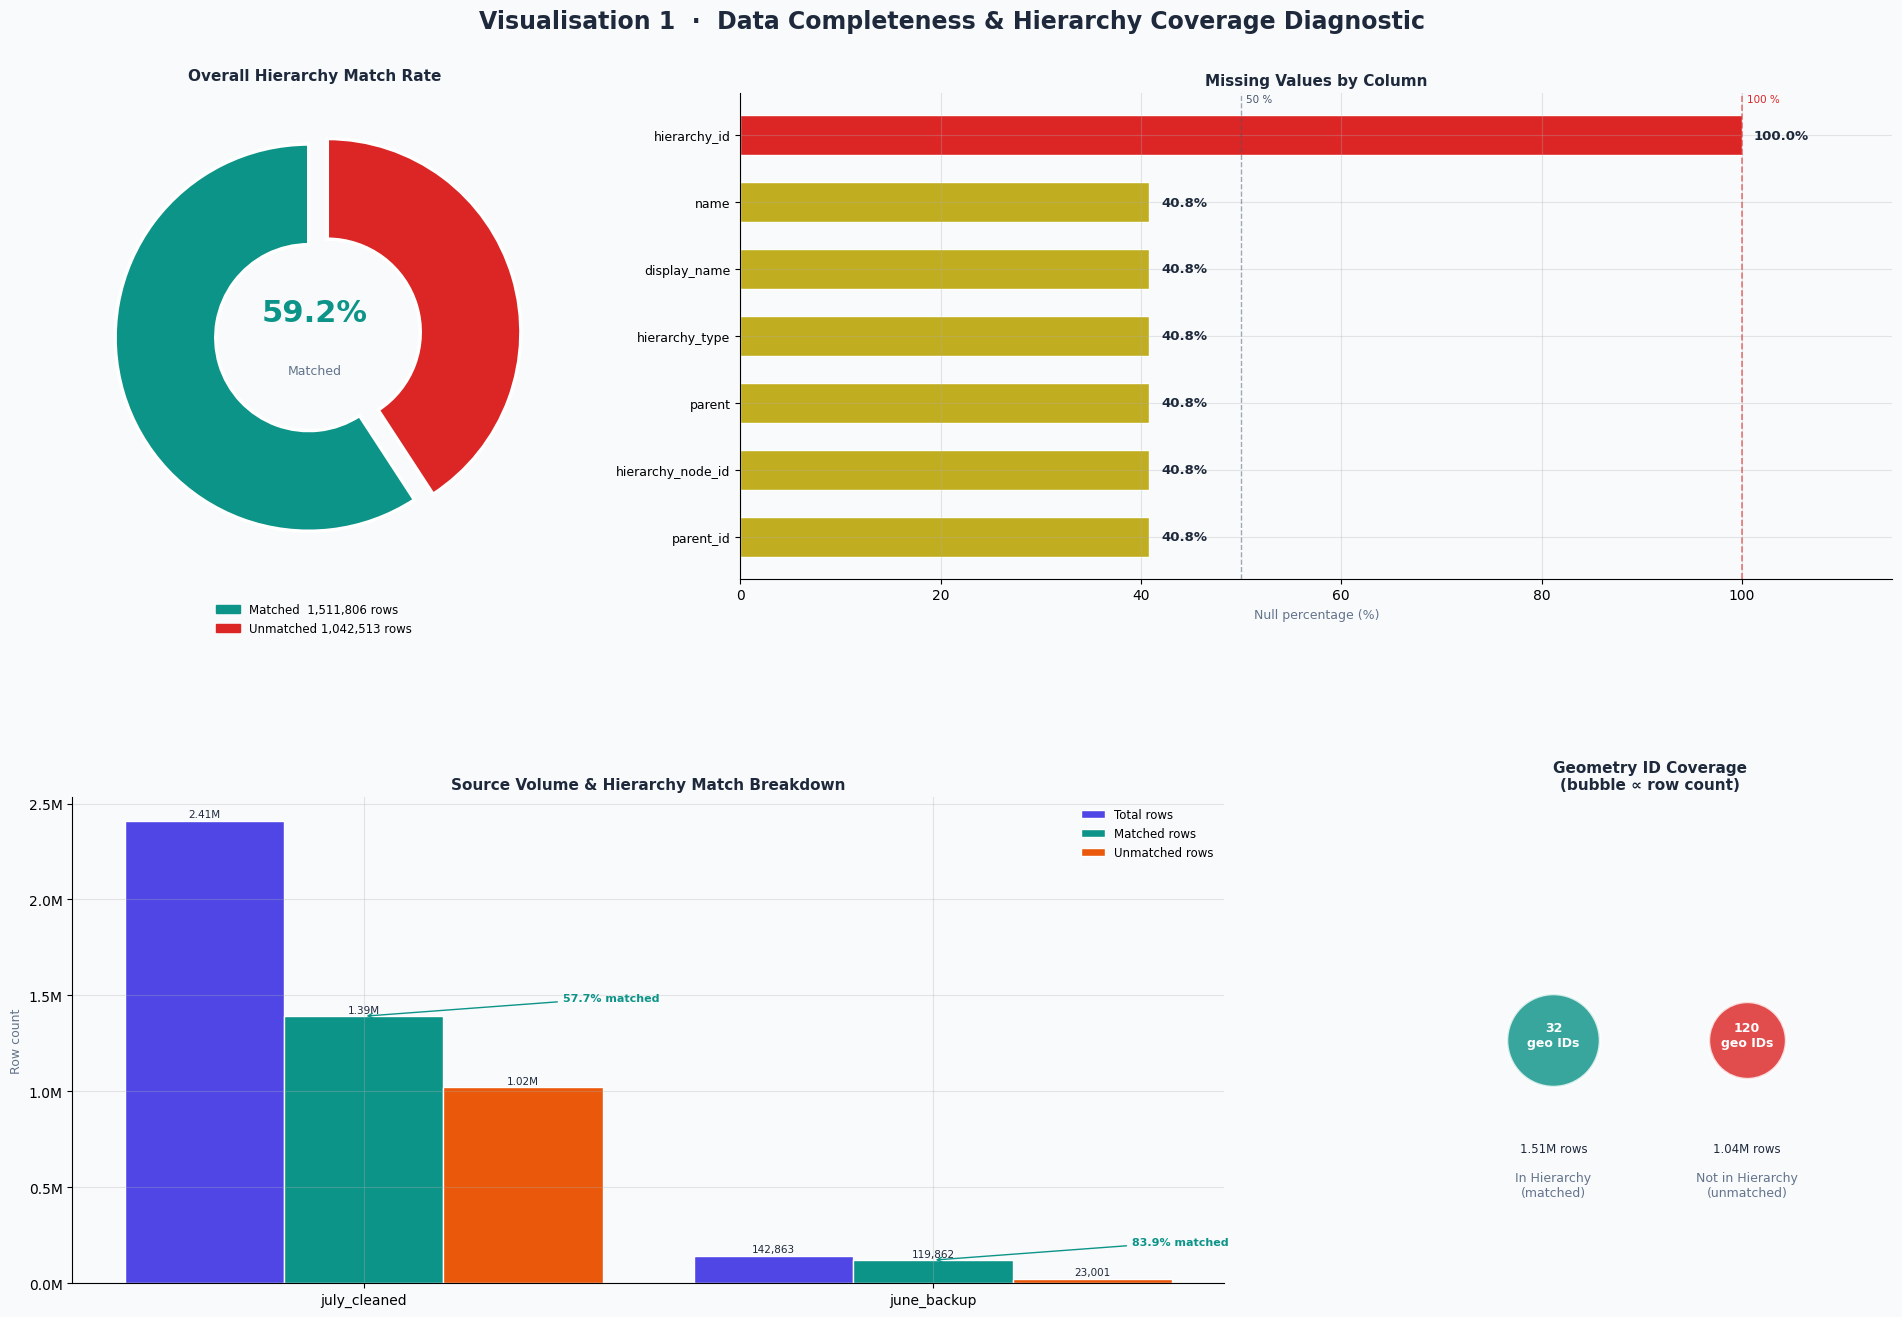

Saved → viz1_completeness_diagnostic.png


In [59]:
fig = plt.figure(figsize=(20, 14), facecolor=C['bg'])
fig.suptitle(
    'Visualisation 1  ·  Data Completeness & Hierarchy Coverage Diagnostic',
    fontsize=17, fontweight='bold', color=C['text'], y=0.98
)

gs = gridspec.GridSpec(
    2, 3, figure=fig,
    hspace=0.45, wspace=0.38,
    left=0.06, right=0.97, top=0.92, bottom=0.07
)

# ── 1A  Matched vs Unmatched donut ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

matched_pct   = 59.2
unmatched_pct = 40.8
sizes  = [matched_pct, unmatched_pct]
colors = [C['teal'], C['red']]
explode = (0.03, 0.07)

wedges, _ = ax1.pie(
    sizes, explode=explode, colors=colors,
    startangle=90, wedgeprops=dict(width=0.52, edgecolor='white', linewidth=2.5)
)
ax1.text(0, 0.12, f'{matched_pct}%',   ha='center', va='center',
         fontsize=22, fontweight='bold', color=C['teal'])
ax1.text(0, -0.18, 'Matched',          ha='center', va='center',
         fontsize=9,  color=C['muted'])

legend_patches = [
    mpatches.Patch(color=C['teal'], label=f'Matched  1,511,806 rows'),
    mpatches.Patch(color=C['red'],  label=f'Unmatched 1,042,513 rows'),
]
ax1.legend(handles=legend_patches, loc='lower center',
           bbox_to_anchor=(0.5, -0.14), fontsize=8.5,
           frameon=False, ncol=1)
ax1.set_title('Overall Hierarchy Match Rate', fontsize=11,
              fontweight='bold', color=C['text'], pad=10)

# ── 1B  Missing-value heatmap ──────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1:])

fields = [
    'hierarchy_id', 'name', 'display_name',
    'hierarchy_type', 'parent', 'hierarchy_node_id', 'parent_id'
]
null_pcts = [100.0, 40.81, 40.81, 40.81, 40.81, 40.81, 40.81]

cmap = LinearSegmentedColormap.from_list(
    'completeness', [C['teal'], C['yellow'], C['red']]
)
bar_colors = [cmap(v / 100) for v in null_pcts]

bars = ax2.barh(fields[::-1], null_pcts[::-1], color=bar_colors[::-1],
                edgecolor='white', height=0.6)

for bar, pct in zip(bars, null_pcts[::-1]):
    ax2.text(bar.get_width() + 1.2, bar.get_y() + bar.get_height() / 2,
             f'{pct:.1f}%', va='center', fontsize=9.5,
             fontweight='bold', color=C['text'])

ax2.set_xlim(0, 115)
ax2.set_xlabel('Null percentage (%)', fontsize=9, color=C['muted'])
ax2.set_title('Missing Values by Column', fontsize=11,
              fontweight='bold', color=C['text'])
ax2.axvline(50, color=C['slate'], lw=1, ls='--', alpha=0.5)
ax2.axvline(100, color=C['red'], lw=1.2, ls='--', alpha=0.6)
ax2.text(50.5, 6.5, '50 %', fontsize=7.5, color=C['slate'])
ax2.text(100.5, 6.5, '100 %', fontsize=7.5, color=C['red'])
ax2.tick_params(axis='y', labelsize=9)
ax2.set_facecolor(C['bg'])
ax2.spines[['top', 'right']].set_visible(False)

# ── 1C  Source × match-rate grouped bar ───────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0:2])

sources       = ['july_cleaned', 'june_backup']
total_rows    = [2411456, 142863]
matched_rows  = [int(2411456 * 0.577), int(142863 * 0.839)]
unmatched_rows = [t - m for t, m in zip(total_rows, matched_rows)]

x    = np.arange(len(sources))
w    = 0.28

b1 = ax3.bar(x - w, total_rows,     width=w, color=C['indigo'], label='Total rows',     edgecolor='white')
b2 = ax3.bar(x,     matched_rows,   width=w, color=C['teal'],   label='Matched rows',   edgecolor='white')
b3 = ax3.bar(x + w, unmatched_rows, width=w, color=C['orange'], label='Unmatched rows', edgecolor='white')

for bar in [*b1, *b2, *b3]:
    h = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width() / 2, h + 18000,
             f'{h/1e6:.2f}M' if h > 500000 else f'{h:,}',
             ha='center', fontsize=7.5, color=C['text'])

ax3.set_xticks(x)
ax3.set_xticklabels(sources, fontsize=10)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M'))
ax3.set_ylabel('Row count', fontsize=9, color=C['muted'])
ax3.set_title('Source Volume & Hierarchy Match Breakdown', fontsize=11,
              fontweight='bold', color=C['text'])
ax3.legend(fontsize=8.5, frameon=False)
ax3.set_facecolor(C['bg'])
ax3.spines[['top', 'right']].set_visible(False)

# Annotate match-rate %
for i, (s, pct) in enumerate(zip(sources, [57.7, 83.9])):
    ax3.annotate(f'{pct}% matched', xy=(i, matched_rows[i]),
                 xytext=(i + 0.35, matched_rows[i] + 80000),
                 fontsize=8, color=C['teal'], fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=C['teal'], lw=1))

# ── 1D  Geometry coverage bubble ──────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])

categories  = ['In Hierarchy\n(matched)', 'Not in Hierarchy\n(unmatched)']
geo_counts  = [32, 120]
row_counts  = [1511806, 1042513]
colors_geo  = [C['teal'], C['red']]

scatter_x   = [0.3, 0.7]
max_r       = max(row_counts)
sizes       = [(r / max_r) * 4500 for r in row_counts]

for sx, sy, sz, col, gc, rc in zip(
        scatter_x, [0.5, 0.5], sizes, colors_geo, geo_counts, row_counts):
    ax4.scatter(sx, sy, s=sz, color=col, alpha=0.82, edgecolors='white', linewidth=2)
    ax4.text(sx, sy + 0.01, f'{gc}\ngeo IDs', ha='center', va='center',
             fontsize=9, fontweight='bold', color='white')
    ax4.text(sx, sy - 0.23, f'{rc/1e6:.2f}M rows', ha='center',
             fontsize=8.5, color=C['text'])
    ax4.text(sx, 0.18, categories[scatter_x.index(sx)], ha='center',
             fontsize=9, color=C['muted'])

ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
ax4.axis('off')
ax4.set_title('Geometry ID Coverage\n(bubble ∝ row count)', fontsize=11,
              fontweight='bold', color=C['text'])

plt.savefig('viz1_completeness_diagnostic.png', dpi=150,
            bbox_inches='tight', facecolor=C['bg'])
plt.show()
print("Saved → viz1_completeness_diagnostic.png")

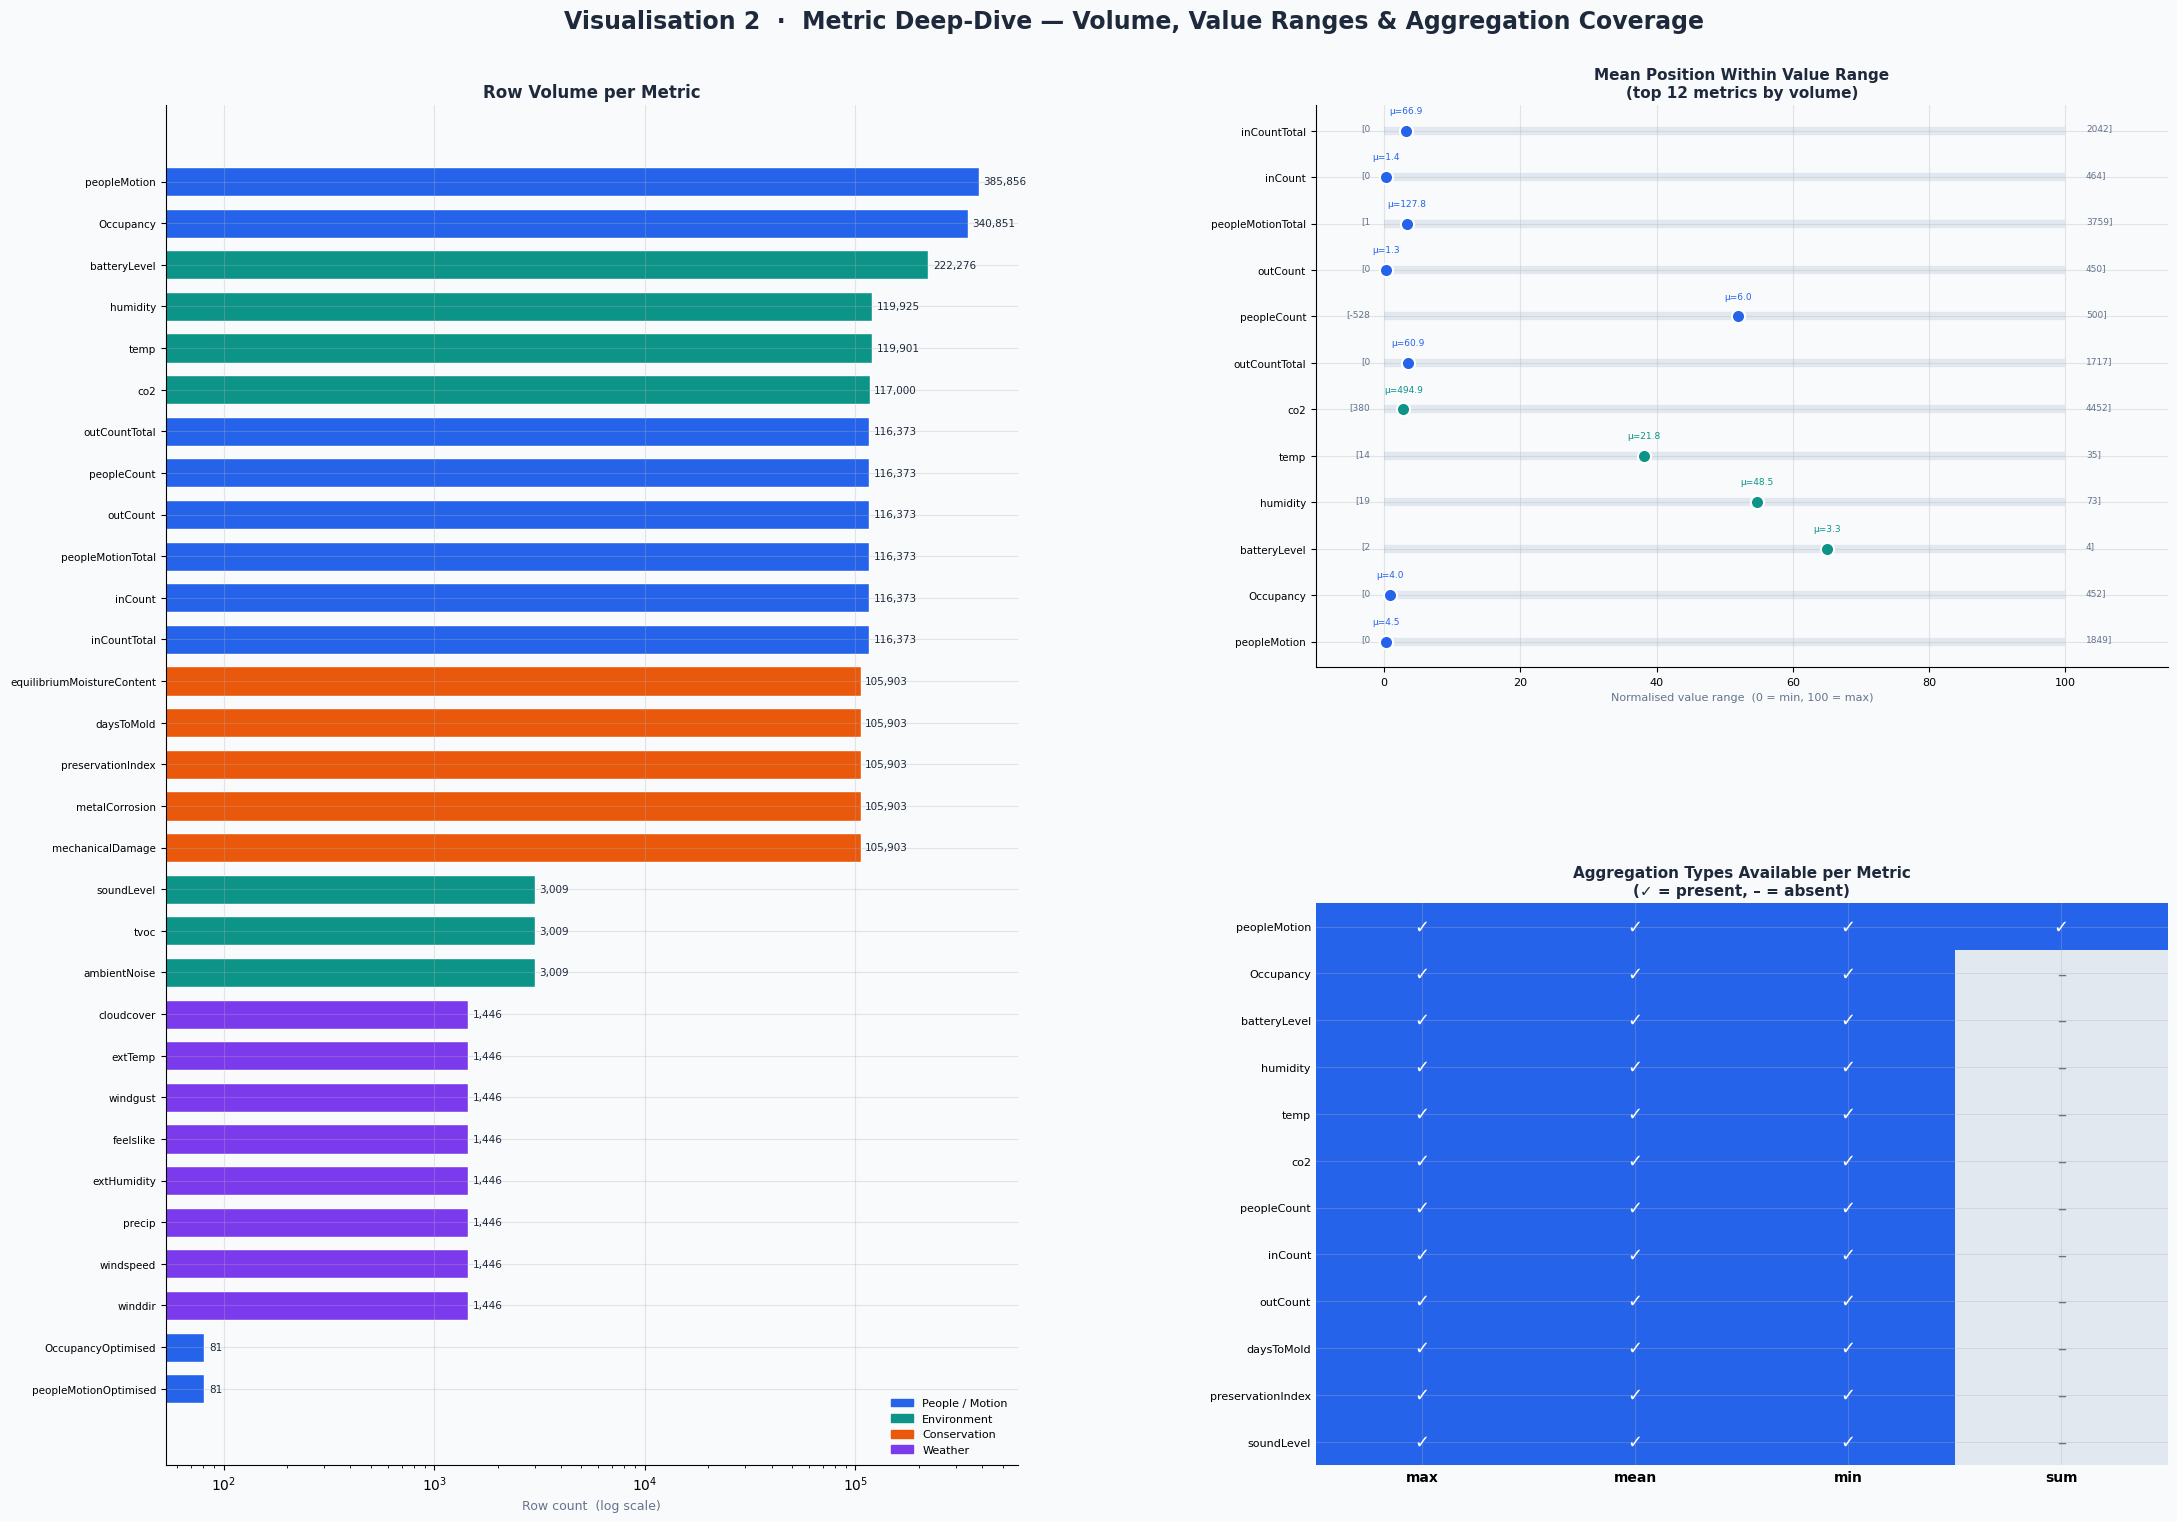

Saved → viz2_metric_deepdive.png


In [60]:
fig = plt.figure(figsize=(22, 16), facecolor=C['bg'])
fig.suptitle(
    'Visualisation 2  ·  Metric Deep-Dive — Volume, Value Ranges & Aggregation Coverage',
    fontsize=17, fontweight='bold', color=C['text'], y=0.98
)

gs = gridspec.GridSpec(
    2, 2, figure=fig,
    hspace=0.42, wspace=0.35,
    left=0.06, right=0.97, top=0.92, bottom=0.07
)

# ─── data ──────────────────────────────────────────────────────────────────
metrics_data = {
    'peopleMotion'             : {'rows': 385856, 'min': 0,    'max': 1849,  'mean': 4.49,   'agg': 4},
    'Occupancy'                : {'rows': 340851, 'min': 0,    'max': 452,   'mean': 3.99,   'agg': 3},
    'batteryLevel'             : {'rows': 222276, 'min': 2.4,  'max': 3.8,   'mean': 3.31,   'agg': 3},
    'humidity'                 : {'rows': 119925, 'min': 19,   'max': 73,    'mean': 48.53,  'agg': 3},
    'temp'                     : {'rows': 119901, 'min': 13.8, 'max': 34.8,  'mean': 21.81,  'agg': 3},
    'co2'                      : {'rows': 117000, 'min': 380,  'max': 4452,  'mean': 494.91, 'agg': 3},
    'outCountTotal'            : {'rows': 116373, 'min': 0,    'max': 1717,  'mean': 60.90,  'agg': 3},
    'peopleCount'              : {'rows': 116373, 'min': -528, 'max': 500,   'mean': 5.97,   'agg': 3},
    'outCount'                 : {'rows': 116373, 'min': 0,    'max': 450,   'mean': 1.31,   'agg': 3},
    'peopleMotionTotal'        : {'rows': 116373, 'min': 1,    'max': 3759,  'mean': 127.77, 'agg': 3},
    'inCount'                  : {'rows': 116373, 'min': 0,    'max': 464,   'mean': 1.44,   'agg': 3},
    'inCountTotal'             : {'rows': 116373, 'min': 0,    'max': 2042,  'mean': 66.87,  'agg': 3},
    'equilibriumMoistureContent': {'rows':105903, 'min': 3.9,  'max': 13.9,  'mean': 8.93,   'agg': 3},
    'daysToMold'               : {'rows': 105903, 'min': 0,    'max': 763,   'mean': 0.49,   'agg': 3},
    'preservationIndex'        : {'rows': 105903, 'min': 7,    'max': 89,    'mean': 38.68,  'agg': 3},
    'metalCorrosion'           : {'rows': 105903, 'min': 0,    'max': 2,     'mean': 0.93,   'agg': 3},
    'mechanicalDamage'         : {'rows': 105903, 'min': 0,    'max': 1,     'mean': 1.00,   'agg': 3},
    'soundLevel'               : {'rows': 3009,   'min': 0,    'max': 77,    'mean': 32.02,  'agg': 3},
    'tvoc'                     : {'rows': 3009,   'min': 0,    'max': 4.3,   'mean': 1.75,   'agg': 3},
    'ambientNoise'             : {'rows': 3009,   'min': 0,    'max': 75,    'mean': 29.14,  'agg': 3},
    'cloudcover'               : {'rows': 1446,   'min': 0,    'max': 100,   'mean': 49.79,  'agg': 3},
    'extTemp'                  : {'rows': 1446,   'min': 3.8,  'max': 27,    'mean': 13.42,  'agg': 3},
    'windgust'                 : {'rows': 1446,   'min': 3.2,  'max': 47.5,  'mean': 22.29,  'agg': 3},
    'feelslike'                : {'rows': 1446,   'min': 0.9,  'max': 26.5,  'mean': 13.04,  'agg': 3},
    'extHumidity'              : {'rows': 1446,   'min': 26.39,'max': 95.34, 'mean': 64.62,  'agg': 3},
    'precip'                   : {'rows': 1446,   'min': 0,    'max': 0.2,   'mean': 0.003,  'agg': 3},
    'windspeed'                : {'rows': 1446,   'min': 1.1,  'max': 23,    'mean': 10.11,  'agg': 3},
    'winddir'                  : {'rows': 1446,   'min': 0.1,  'max': 359.9, 'mean': 77.57,  'agg': 3},
    'OccupancyOptimised'       : {'rows': 81,     'min': 0,    'max': 136,   'mean': 10.85,  'agg': 3},
    'peopleMotionOptimised'    : {'rows': 81,     'min': 0,    'max': 36,    'mean': 3.98,   'agg': 3},
}

df_m = pd.DataFrame(metrics_data).T.reset_index()
df_m.columns = ['metric', 'rows', 'min', 'max', 'mean', 'agg']
df_m = df_m.sort_values('rows', ascending=False).reset_index(drop=True)

# Assign colour groups
groups = {
    'People / Motion' : ['peopleMotion','Occupancy','peopleCount','inCount','outCount',
                          'inCountTotal','outCountTotal','peopleMotionTotal',
                          'OccupancyOptimised','peopleMotionOptimised'],
    'Environment'     : ['humidity','temp','co2','batteryLevel','soundLevel',
                          'tvoc','ambientNoise'],
    'Conservation'    : ['equilibriumMoistureContent','daysToMold','preservationIndex',
                          'metalCorrosion','mechanicalDamage'],
    'Weather'         : ['cloudcover','extTemp','windgust','feelslike','extHumidity',
                          'precip','windspeed','winddir'],
}
group_colors = {
    'People / Motion': C['blue'],
    'Environment'    : C['teal'],
    'Conservation'   : C['orange'],
    'Weather'        : C['purple'],
}

def get_group_color(m):
    for g, mlist in groups.items():
        if m in mlist:
            return group_colors[g]
    return C['slate']

df_m['color'] = df_m['metric'].apply(get_group_color)

# ── 2A  Horizontal row-count bar (log scale) ──────────────────────────────
ax1 = fig.add_subplot(gs[:, 0])

bar_colors_a = df_m['color'].tolist()
bars = ax1.barh(df_m['metric'][::-1], df_m['rows'][::-1],
                color=bar_colors_a[::-1], edgecolor='white', height=0.7)

for bar, row in zip(bars, df_m['rows'][::-1]):
    ax1.text(bar.get_width() * 1.05, bar.get_y() + bar.get_height() / 2,
             f'{int(row):,}', va='center', fontsize=7.5, color=C['text'])

ax1.set_xscale('log')
ax1.set_xlabel('Row count  (log scale)', fontsize=9, color=C['muted'])
ax1.set_title('Row Volume per Metric', fontsize=12, fontweight='bold', color=C['text'])
ax1.spines[['top', 'right']].set_visible(False)
ax1.tick_params(axis='y', labelsize=7.5)
ax1.set_facecolor(C['bg'])

legend_handles = [mpatches.Patch(color=v, label=k) for k, v in group_colors.items()]
ax1.legend(handles=legend_handles, loc='lower right', fontsize=8, frameon=False)

# ── 2B  Float-range lollipop (mean + range bar) ──────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

# Normalise each metric's range to 0-100 for comparability
top12 = df_m.head(12).copy()
top12['range'] = top12['max'] - top12['min']
top12['norm_min']  = 0
top12['norm_max']  = 100
top12['norm_mean'] = ((top12['mean'] - top12['min']) /
                       top12['range'].replace(0, 1) * 100)

y_pos = np.arange(len(top12))

for i, (_, row) in enumerate(top12.iterrows()):
    col = get_group_color(row['metric'])
    ax2.hlines(i, 0, 100, color=C['border'], lw=6, zorder=1)
    ax2.scatter(row['norm_mean'], i, color=col, s=90, zorder=3, edgecolors='white', lw=1.5)
    ax2.text(row['norm_mean'], i + 0.38, f"μ={row['mean']:.1f}",
             ha='center', fontsize=6.5, color=col)
    ax2.text(-2, i, f"[{row['min']:.0f}", ha='right', fontsize=6.5, color=C['muted'])
    ax2.text(103, i, f"{row['max']:.0f}]", ha='left', fontsize=6.5, color=C['muted'])

ax2.set_yticks(y_pos)
ax2.set_yticklabels(top12['metric'], fontsize=7.5)
ax2.set_xlim(-10, 115)
ax2.set_xlabel('Normalised value range  (0 = min, 100 = max)', fontsize=8, color=C['muted'])
ax2.set_title('Mean Position Within Value Range\n(top 12 metrics by volume)',
              fontsize=11, fontweight='bold', color=C['text'])
ax2.spines[['top', 'right']].set_visible(False)
ax2.set_facecolor(C['bg'])
ax2.tick_params(axis='x', labelsize=8)

# ── 2C  Aggregation type heatmap ─────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])

agg_matrix = {
    'peopleMotion': [1, 1, 1, 1],
    'Occupancy'   : [1, 1, 1, 0],
    'batteryLevel': [1, 1, 1, 0],
    'humidity'    : [1, 1, 1, 0],
    'temp'        : [1, 1, 1, 0],
    'co2'         : [1, 1, 1, 0],
    'peopleCount' : [1, 1, 1, 0],
    'inCount'     : [1, 1, 1, 0],
    'outCount'    : [1, 1, 1, 0],
    'daysToMold'  : [1, 1, 1, 0],
    'preservationIndex': [1, 1, 1, 0],
    'soundLevel'  : [1, 1, 1, 0],
}

agg_labels = ['max', 'mean', 'min', 'sum']
mat  = np.array(list(agg_matrix.values()))
mets = list(agg_matrix.keys())

cmap2 = LinearSegmentedColormap.from_list('agg', [C['border'], C['blue']])
im = ax3.imshow(mat, cmap=cmap2, aspect='auto', vmin=0, vmax=1)

for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        sym = '✓' if mat[i, j] else '–'
        col = 'white' if mat[i, j] else C['muted']
        ax3.text(j, i, sym, ha='center', va='center', fontsize=13, color=col)

ax3.set_xticks(range(4))
ax3.set_xticklabels(agg_labels, fontsize=10, fontweight='bold')
ax3.set_yticks(range(len(mets)))
ax3.set_yticklabels(mets, fontsize=8)
ax3.set_title('Aggregation Types Available per Metric\n(✓ = present, – = absent)',
              fontsize=11, fontweight='bold', color=C['text'])
ax3.spines[:].set_visible(False)
ax3.tick_params(length=0)

plt.savefig('viz2_metric_deepdive.png', dpi=150,
            bbox_inches='tight', facecolor=C['bg'])
plt.show()
print("Saved → viz2_metric_deepdive.png")

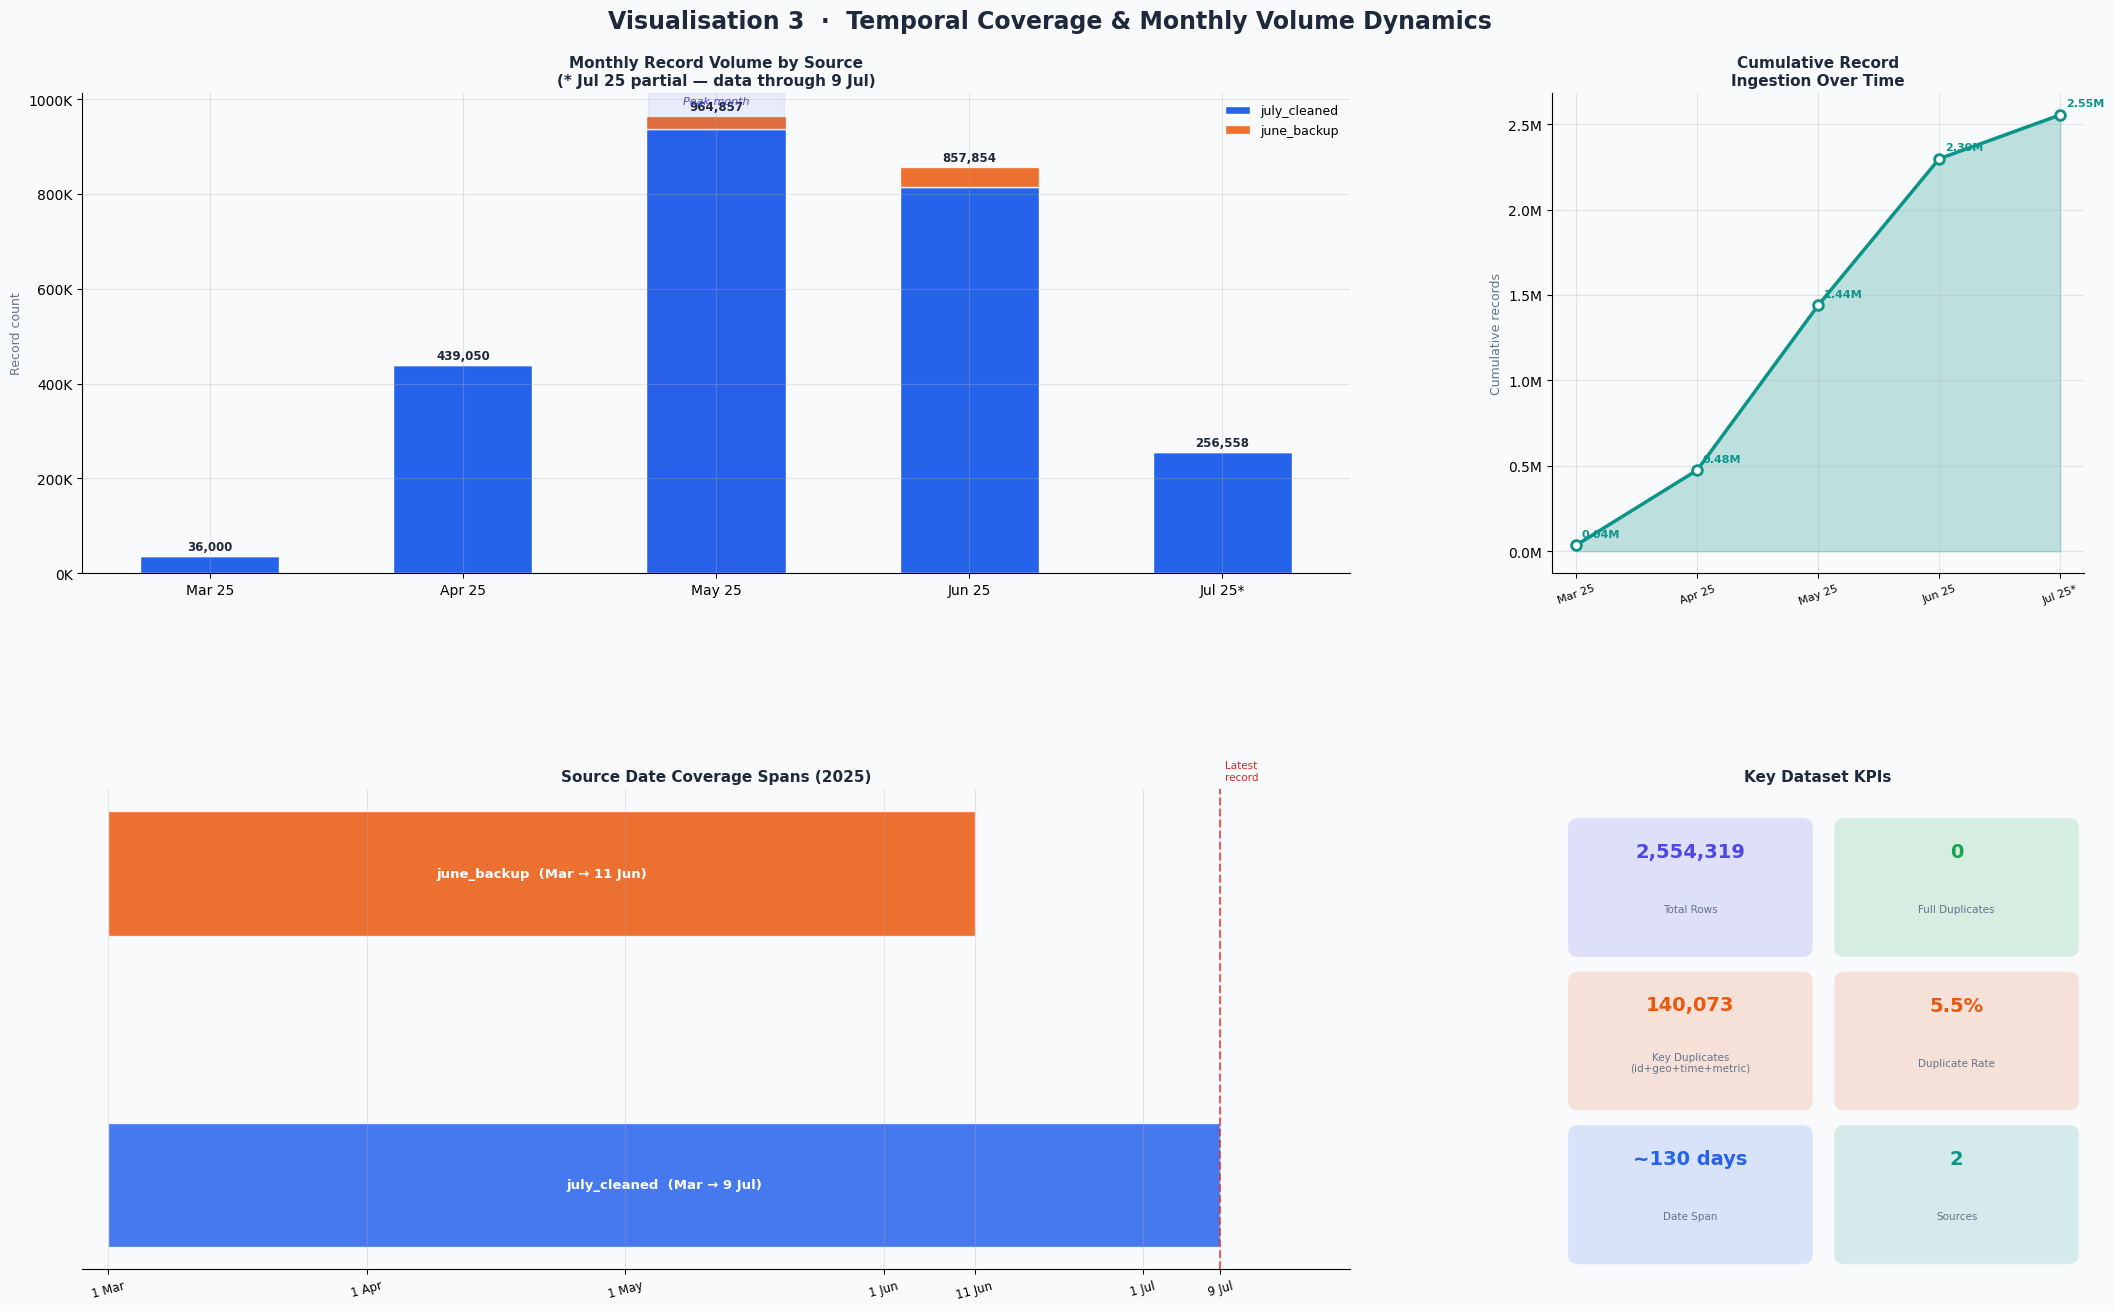

Saved → viz3_temporal_coverage.png


In [61]:
fig = plt.figure(figsize=(22, 14), facecolor=C['bg'])
fig.suptitle(
    'Visualisation 3  ·  Temporal Coverage & Monthly Volume Dynamics',
    fontsize=17, fontweight='bold', color=C['text'], y=0.98
)

gs = gridspec.GridSpec(
    2, 3, figure=fig,
    hspace=0.45, wspace=0.38,
    left=0.06, right=0.97, top=0.92, bottom=0.08
)

# ─── data ─────────────────────────────────────────────────────────────────
months        = ['Mar 25', 'Apr 25', 'May 25', 'Jun 25', 'Jul 25*']
total_records = [36000, 439050, 964857, 857854, 256558]
month_colors  = [C['sky'], C['blue'], C['indigo'], C['purple'], C['pink']]

# Approximate source split per month (derived from date ranges)
july_records  = [36000, 439050, 937000, 815000, 256558]  # july_cleaned dominates
june_records  = [0,         0,  27857,  42854,      0]   # june_backup ~Mar-Jun

# ── 3A  Stacked monthly bar ────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])

x  = np.arange(len(months))
b1 = ax1.bar(x, july_records, color=C['blue'],   label='july_cleaned', edgecolor='white', width=0.55)
b2 = ax1.bar(x, june_records, bottom=july_records,
             color=C['orange'], label='june_backup',  edgecolor='white', width=0.55, alpha=0.85)

for i, (jl, jb, tot) in enumerate(zip(july_records, june_records, total_records)):
    ax1.text(i, tot + 12000, f'{tot:,}',
             ha='center', fontsize=8.5, fontweight='bold', color=C['text'])

ax1.set_xticks(x)
ax1.set_xticklabels(months, fontsize=10)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e3:.0f}K'))
ax1.set_ylabel('Record count', fontsize=9, color=C['muted'])
ax1.set_title('Monthly Record Volume by Source\n(* Jul 25 partial — data through 9 Jul)',
              fontsize=11, fontweight='bold', color=C['text'])
ax1.legend(fontsize=9, frameon=False)
ax1.set_facecolor(C['bg'])
ax1.spines[['top', 'right']].set_visible(False)

# Shade peak month
ax1.axvspan(1.73, 2.27, alpha=0.08, color=C['indigo'])
ax1.text(2, 990000, 'Peak month', ha='center', fontsize=8, color=C['indigo'], style='italic')

# ── 3B  Cumulative volume area ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])

cumulative = np.cumsum(total_records)
ax2.fill_between(range(5), cumulative, alpha=0.25, color=C['teal'])
ax2.plot(range(5), cumulative, color=C['teal'], lw=2.5, marker='o',
         markersize=7, markerfacecolor='white', markeredgecolor=C['teal'], markeredgewidth=2)

for i, (c, m) in enumerate(zip(cumulative, months)):
    ax2.annotate(f'{c/1e6:.2f}M', (i, c),
                 textcoords='offset points', xytext=(4, 6),
                 fontsize=8, color=C['teal'], fontweight='bold')

ax2.set_xticks(range(5))
ax2.set_xticklabels(months, fontsize=8, rotation=20)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1e6:.1f}M'))
ax2.set_ylabel('Cumulative records', fontsize=9, color=C['muted'])
ax2.set_title('Cumulative Record\nIngestion Over Time', fontsize=11,
              fontweight='bold', color=C['text'])
ax2.set_facecolor(C['bg'])
ax2.spines[['top', 'right']].set_visible(False)

# ── 3C  Source date span Gantt ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])

gantt_data = [
    {'source': 'july_cleaned', 'start': 0, 'end': 4.3,  'color': C['blue'],   'label': 'Mar → 9 Jul'},
    {'source': 'june_backup',  'start': 0, 'end': 3.35, 'color': C['orange'], 'label': 'Mar → 11 Jun'},
]

month_ticks = [0, 1, 2, 3, 3.35, 4, 4.3]
month_labels = ['1 Mar', '1 Apr', '1 May', '1 Jun', '11 Jun', '1 Jul', '9 Jul']

for i, g in enumerate(gantt_data):
    ax3.barh(i, g['end'] - g['start'], left=g['start'],
             height=0.4, color=g['color'], edgecolor='white', alpha=0.85)
    ax3.text((g['start'] + g['end']) / 2, i,
             f"{g['source']}  ({g['label']})",
             ha='center', va='center', fontsize=9.5,
             fontweight='bold', color='white')

ax3.set_yticks([])
ax3.set_xticks(month_ticks)
ax3.set_xticklabels(month_labels, fontsize=8.5, rotation=15)
ax3.set_xlim(-0.1, 4.8)
ax3.set_title('Source Date Coverage Spans (2025)', fontsize=11,
              fontweight='bold', color=C['text'])
ax3.set_facecolor(C['bg'])
ax3.spines[['top', 'right', 'left']].set_visible(False)

# Vertical today line
ax3.axvline(4.3, color=C['red'], lw=1.5, ls='--', alpha=0.7)
ax3.text(4.32, 1.3, 'Latest\nrecord', fontsize=7.5, color=C['red'])

# ── 3D  Key duplicates KPI tiles ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
ax4.axis('off')

kpi_data = [
    ('Total Rows',              '2,554,319', C['indigo']),
    ('Full Duplicates',         '0',         C['green']),
    ('Key Duplicates\n(id+geo+time+metric)', '140,073', C['orange']),
    ('Duplicate Rate',          '5.5%',      C['orange']),
    ('Date Span',               '~130 days', C['blue']),
    ('Sources',                 '2',         C['teal']),
]

cols, rows_k = 2, 3
for idx, (label, val, col) in enumerate(kpi_data):
    c = idx % cols
    r = idx // cols
    x0 = 0.05 + c * 0.50
    y0 = 0.85 - r * 0.32

    rect = mpatches.FancyBboxPatch(
        (x0, y0 - 0.18), 0.42, 0.25,
        boxstyle='round,pad=0.02',
        facecolor=col, edgecolor='white', linewidth=1.5,
        transform=ax4.transAxes, clip_on=False, alpha=0.15
    )
    ax4.add_patch(rect)

    ax4.text(x0 + 0.21, y0 + 0.02, val, ha='center', va='center',
             fontsize=14, fontweight='bold', color=col,
             transform=ax4.transAxes)
    ax4.text(x0 + 0.21, y0 - 0.10, label, ha='center', va='center',
             fontsize=7.5, color=C['muted'],
             transform=ax4.transAxes)

ax4.set_title('Key Dataset KPIs', fontsize=11, fontweight='bold', color=C['text'])

plt.savefig('viz3_temporal_coverage.png', dpi=150,
            bbox_inches='tight', facecolor=C['bg'])
plt.show()
print("Saved → viz3_temporal_coverage.png")

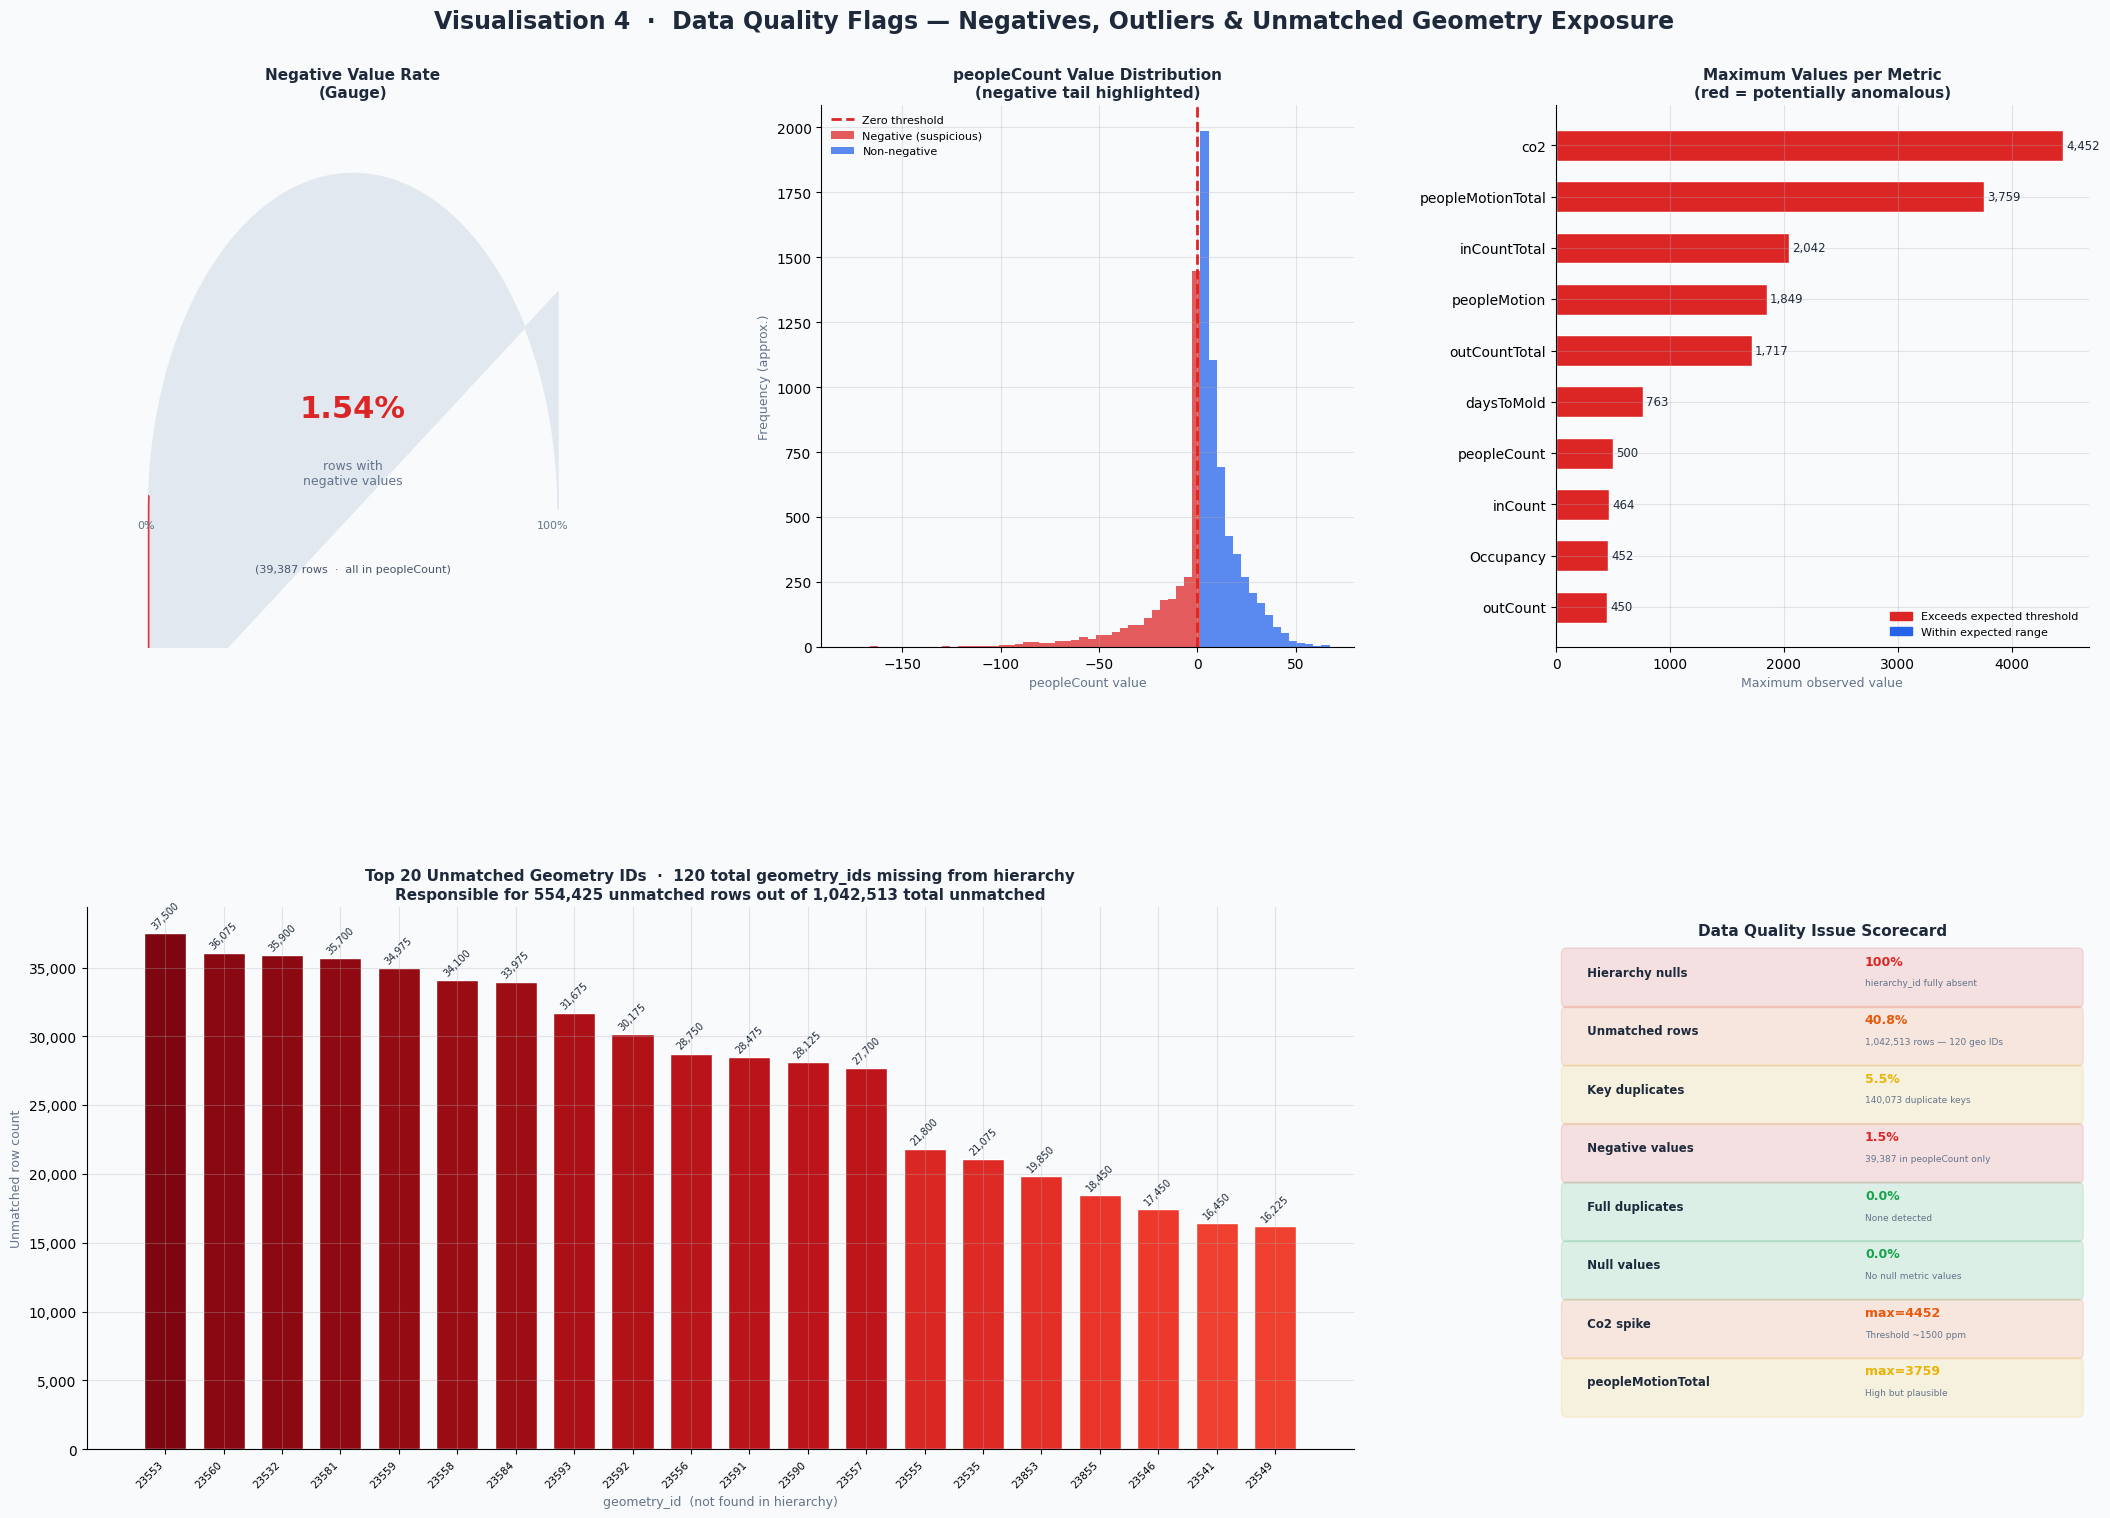

Saved → viz4_quality_flags.png


In [63]:
fig = plt.figure(figsize=(22, 16), facecolor=C['bg'])
fig.suptitle(
    'Visualisation 4  ·  Data Quality Flags — Negatives, Outliers & Unmatched Geometry Exposure',
    fontsize=17, fontweight='bold', color=C['text'], y=0.98
)

gs = gridspec.GridSpec(
    2, 3, figure=fig,
    hspace=0.48, wspace=0.38,
    left=0.06, right=0.97, top=0.92, bottom=0.08
)

# ── 4A  Negative values severity gauge ───────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])

total = 2554319
neg   = 39387
pct   = neg / total * 100

# Semicircle gauge
theta = np.linspace(np.pi, 0, 300)
r_outer, r_inner = 1.0, 0.65

# Background arc (grey)
ax1.fill_between(np.cos(theta) * r_outer, np.sin(theta) * r_outer,
                 np.cos(theta) * r_inner, np.sin(theta) * r_inner,
                 color=C['border'], zorder=1)

# Filled arc (red — proportional to pct)
fill_theta = np.linspace(np.pi, np.pi - (pct / 100 * np.pi), 300)
ax1.fill_between(np.cos(fill_theta) * r_outer, np.sin(fill_theta) * r_outer,
                 np.cos(fill_theta) * r_inner, np.sin(fill_theta) * r_inner,
                 color=C['red'], zorder=2, alpha=0.85)

ax1.text(0, 0.28, f'{pct:.2f}%', ha='center', fontsize=22,
         fontweight='bold', color=C['red'])
ax1.text(0, 0.08, 'rows with\nnegative values', ha='center', fontsize=9, color=C['muted'])
ax1.text(0, -0.18, f'({neg:,} rows  ·  all in peopleCount)',
         ha='center', fontsize=8, color=C['slate'])

ax1.text(-1.05, -0.05, '0%',   fontsize=8, color=C['muted'])
ax1.text(0.9,  -0.05, '100%',  fontsize=8, color=C['muted'])
ax1.set_xlim(-1.3, 1.3)
ax1.set_ylim(-0.4, 1.2)
ax1.axis('off')
ax1.set_title('Negative Value Rate\n(Gauge)', fontsize=11,
              fontweight='bold', color=C['text'])

# ── 4B  peopleCount distribution sketch ──────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])

np.random.seed(42)
# Approximate bimodal: mostly 0-50 positive, with negative tail -528 to 0
pos_vals = np.concatenate([
    np.random.exponential(6, 5000),
    np.random.normal(20, 15, 2000),
])
pos_vals = pos_vals[pos_vals <= 500]
neg_vals = -np.abs(np.random.exponential(30, 1800))
neg_vals = neg_vals[neg_vals >= -528]
all_vals = np.concatenate([neg_vals, pos_vals])

counts, edges = np.histogram(all_vals, bins=60)
centers = (edges[:-1] + edges[1:]) / 2

neg_mask = centers < 0
ax2.bar(centers[neg_mask],  counts[neg_mask],  width=np.diff(edges)[0],
        color=C['red'],   alpha=0.75, label='Negative (suspicious)')
ax2.bar(centers[~neg_mask], counts[~neg_mask], width=np.diff(edges)[0],
        color=C['blue'],  alpha=0.75, label='Non-negative')

ax2.axvline(0, color=C['red'], lw=2, ls='--', label='Zero threshold')
ax2.set_xlabel('peopleCount value', fontsize=9, color=C['muted'])
ax2.set_ylabel('Frequency (approx.)', fontsize=9, color=C['muted'])
ax2.set_title('peopleCount Value Distribution\n(negative tail highlighted)',
              fontsize=11, fontweight='bold', color=C['text'])
ax2.legend(fontsize=8, frameon=False)
ax2.set_facecolor(C['bg'])
ax2.spines[['top', 'right']].set_visible(False)

# ── 4C  Outlier max-value ranked bar ─────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])

outlier_metrics = ['co2', 'peopleMotionTotal', 'inCountTotal', 'peopleMotion',
                   'outCountTotal', 'daysToMold', 'peopleCount', 'inCount',
                   'Occupancy', 'outCount']
outlier_vals    = [4452, 3759, 2042, 1849, 1717, 763, 500, 464, 452, 450]

thresholds = {   # domain-reasonable upper bounds
    'co2': 1500, 'peopleMotionTotal': 2000, 'inCountTotal': 1500,
    'peopleMotion': 1000, 'outCountTotal': 1000, 'daysToMold': 100,
    'peopleCount': 200, 'inCount': 300, 'Occupancy': 200, 'outCount': 300
}

bar_colors_c = [
    C['red'] if outlier_vals[i] > thresholds.get(outlier_metrics[i], 9e9)
    else C['blue']
    for i in range(len(outlier_metrics))
]

bars = ax3.barh(outlier_metrics[::-1], outlier_vals[::-1],
                color=bar_colors_c[::-1], edgecolor='white', height=0.6)

for bar, val in zip(bars, outlier_vals[::-1]):
    ax3.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
             f'{val:,}', va='center', fontsize=8.5, color=C['text'])

ax3.set_xlabel('Maximum observed value', fontsize=9, color=C['muted'])
ax3.set_title('Maximum Values per Metric\n(red = potentially anomalous)',
              fontsize=11, fontweight='bold', color=C['text'])
ax3.set_facecolor(C['bg'])
ax3.spines[['top', 'right']].set_visible(False)

legend_patches_c = [
    mpatches.Patch(color=C['red'],  label='Exceeds expected threshold'),
    mpatches.Patch(color=C['blue'], label='Within expected range'),
]
ax3.legend(handles=legend_patches_c, fontsize=8, frameon=False)

# ── 4D  Top-20 unmatched geometry_ids bar ───────────────────────────────
ax4 = fig.add_subplot(gs[1, :2])

top_unmatched_geo = {
    23553: 37500, 23560: 36075, 23532: 35900, 23581: 35700, 23559: 34975,
    23558: 34100, 23584: 33975, 23593: 31675, 23592: 30175, 23556: 28750,
    23591: 28475, 23590: 28125, 23557: 27700, 23555: 21800, 23535: 21075,
    23853: 19850, 23855: 18450, 23546: 17450, 23541: 16450, 23549: 16225,
}

geo_ids  = [str(k) for k in top_unmatched_geo.keys()]
geo_cnts = list(top_unmatched_geo.values())

# colour intensity by count
max_c = max(geo_cnts)
bar_colors_d = [plt.cm.Reds(0.35 + 0.6 * v / max_c) for v in geo_cnts]

x = np.arange(len(geo_ids))
bars = ax4.bar(x, geo_cnts, color=bar_colors_d, edgecolor='white', width=0.72)

for bar, cnt in zip(bars, geo_cnts):
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
             f'{cnt:,}', ha='center', fontsize=7, color=C['text'], rotation=45)

ax4.set_xticks(x)
ax4.set_xticklabels(geo_ids, rotation=45, ha='right', fontsize=7.5)
ax4.set_xlabel('geometry_id  (not found in hierarchy)', fontsize=9, color=C['muted'])
ax4.set_ylabel('Unmatched row count', fontsize=9, color=C['muted'])
ax4.set_title(
    f'Top 20 Unmatched Geometry IDs  ·  120 total geometry_ids missing from hierarchy\n'
    f'Responsible for {sum(geo_cnts):,} unmatched rows out of 1,042,513 total unmatched',
    fontsize=11, fontweight='bold', color=C['text']
)
ax4.set_facecolor(C['bg'])
ax4.spines[['top', 'right']].set_visible(False)
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f}'))

# ── 4E  Quality issues summary scorecard ─────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')

issues = [
    (' Hierarchy nulls',    '100%',  'hierarchy_id fully absent', C['red']),
    (' Unmatched rows',     '40.8%', '1,042,513 rows — 120 geo IDs', C['orange']),
    (' Key duplicates',     '5.5%',  '140,073 duplicate keys', C['yellow']),
    (' Negative values',    '1.5%',  '39,387 in peopleCount only', C['red']),
    (' Full duplicates',    '0.0%',  'None detected', C['green']),
    (' Null values',        '0.0%',  'No null metric values', C['green']),
    (' Co2 spike',          'max=4452', 'Threshold ~1500 ppm', C['orange']),
    (' peopleMotionTotal',  'max=3759', 'High but plausible', C['yellow']),
]

ax5.text(0.5, 0.97, 'Data Quality Issue Scorecard',
         ha='center', va='top', fontsize=11, fontweight='bold',
         color=C['text'], transform=ax5.transAxes)

for i, (issue, val, note, col) in enumerate(issues):
    y = 0.88 - i * 0.108
    rect = mpatches.FancyBboxPatch(
        (0.02, y - 0.055), 0.96, 0.09,
        boxstyle='round,pad=0.01',
        facecolor=col, alpha=0.12,
        edgecolor=col, linewidth=1,
        transform=ax5.transAxes, clip_on=False
    )
    ax5.add_patch(rect)
    ax5.text(0.05, y, issue, ha='left', va='center', fontsize=8.5,
             color=C['text'], transform=ax5.transAxes, fontweight='bold')
    ax5.text(0.58, y + 0.02, val,  ha='left', va='center', fontsize=9,
             color=col, transform=ax5.transAxes, fontweight='bold')
    ax5.text(0.58, y - 0.02, note, ha='left', va='center', fontsize=6.5,
             color=C['muted'], transform=ax5.transAxes)

plt.savefig('viz4_quality_flags.png', dpi=150,
            bbox_inches='tight', facecolor=C['bg'])
plt.show()
print("Saved → viz4_quality_flags.png")

In [64]:
df_merged.drop(columns=['hierarchy_id'], inplace=True)  l
print(f"Before dedup : {len(df_merged):,}")
df_merged.sort_values('source', ascending=False, inplace=True)
df_merged.drop_duplicates(
    subset=['geometry_id', 'start_time', 'metric_name', 'aggregation'],
    keep='first',
    inplace=True
)
df_merged.reset_index(drop=True, inplace=True)
print(f"After dedup  : {len(df_merged):,}  (removed {2554319 - len(df_merged):,} duplicates)")
neg_mask = (df_merged['metric_name'] == 'peopleCount') & (df_merged['value'] < 0)
print(f"\nNegative peopleCount rows fixed: {neg_mask.sum():,}")
df_merged.loc[neg_mask, 'value'] = 0
df_merged['in_hierarchy'] = df_merged['display_name'].notna()
print(f"\nin_hierarchy=True  : {df_merged['in_hierarchy'].sum():,}")
print(f"in_hierarchy=False : {(~df_merged['in_hierarchy']).sum():,}")
for col in ['name', 'display_name', 'hierarchy_type', 'parent']:
    df_merged[col].fillna('unknown', inplace=True)
df_merged['hierarchy_node_id'].fillna(-1, inplace=True)
df_merged['parent_id'].fillna(-1, inplace=True)
df_merged['hierarchy_node_id'] = df_merged['hierarchy_node_id'].astype(int)
df_merged['parent_id']         = df_merged['parent_id'].astype(int)
for col in ['metric_name', 'aggregation', 'frequency', 'source', 'hierarchy_type']:
    df_merged[col] = df_merged[col].astype('category')



print(f"  Shape         : {df_merged.shape}")
print(f"  Nulls left    : {df_merged.isnull().sum().sum()}")
print(f"  Negatives left: {(df_merged['value'] < 0).sum()}")
print(f"  Date range    : {df_merged['start_time'].min()} → {df_merged['start_time'].max()}")
print(f"  Metrics       : {df_merged['metric_name'].nunique()}")
print(f"  Geometry IDs  : {df_merged['geometry_id'].nunique()}")
print(f"\n  Memory usage  : {df_merged.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\n  Columns       : {df_merged.columns.tolist()}")
display(df_merged.head())

SyntaxError: invalid syntax (1219651465.py, line 1)

# **EDA**

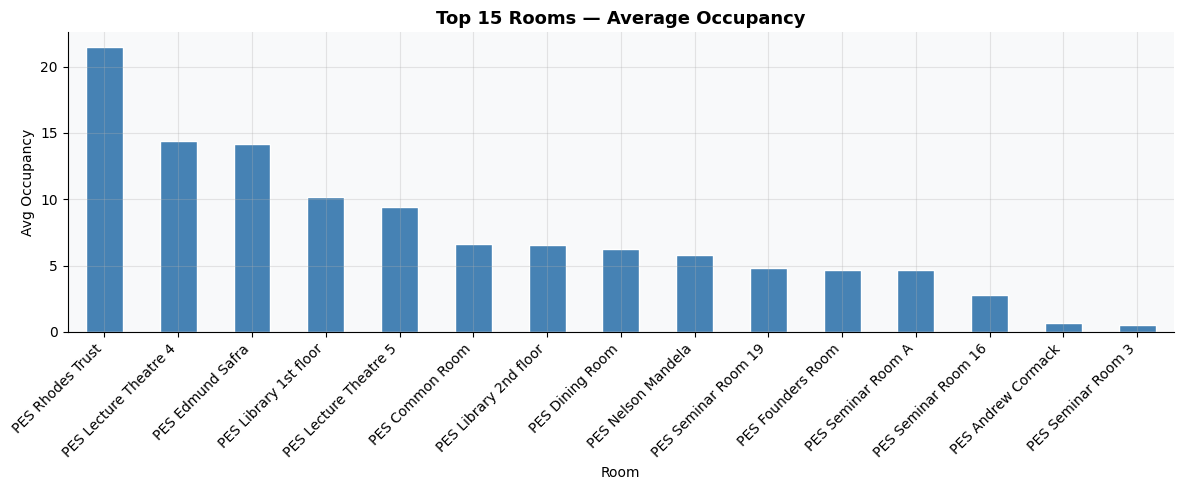

In [65]:

occ = df_merged[
    (df_merged['metric_name'] == 'Occupancy') &
    (df_merged['aggregation'] == 'mean') &
    (df_merged['in_hierarchy'] == True)
]

room_avg = (occ.groupby('display_name')['value']
              .mean()
              .sort_values(ascending=False)
              .head(15))

fig, ax = plt.subplots(figsize=(12, 5))
room_avg.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 15 Rooms — Average Occupancy', fontsize=13, fontweight='bold')
ax.set_xlabel('Room'); ax.set_ylabel('Avg Occupancy')
ax.set_xticklabels(room_avg.index, rotation=45, ha='right')
plt.tight_layout(); plt.show()

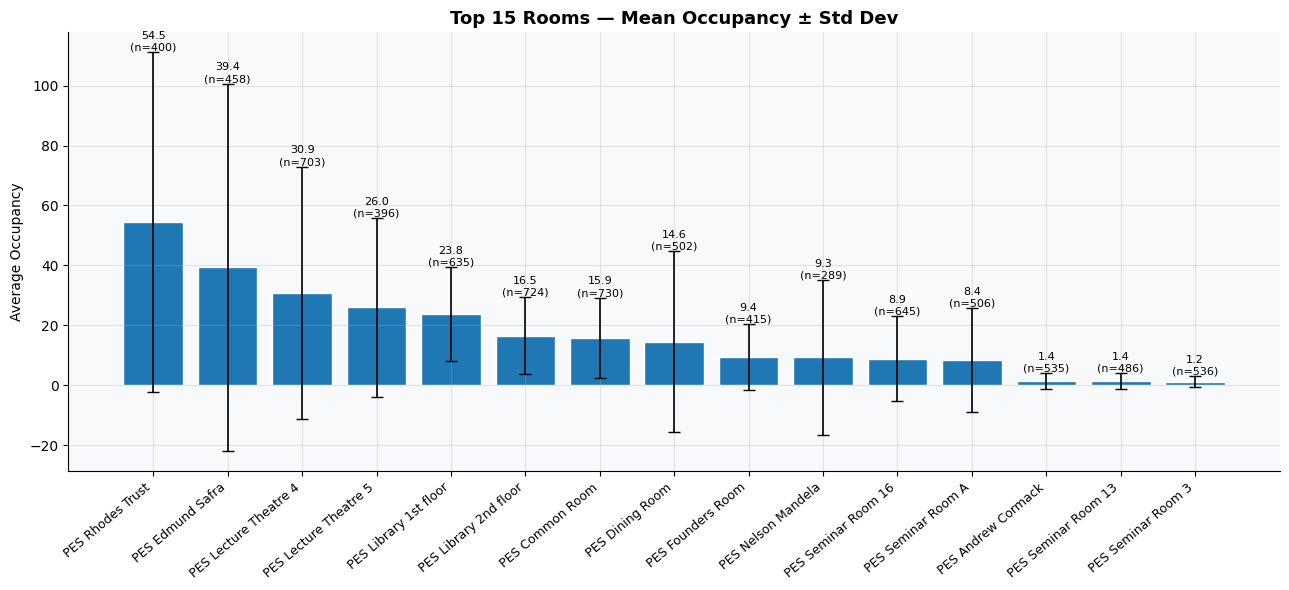

In [66]:
df = df_time_jul.merge(df_hierarchy, on='geometry_id', how='left')
occ = df[
    (df['metric_name'] == 'Occupancy') &
    (df['aggregation'] == 'mean') &
    (df['is_working'] == True)
]

room_stats = occ.groupby('display_name')['value'].agg(['mean', 'std', 'count'])
room_stats = room_stats.sort_values('mean', ascending=False).head(15)
fig, ax = plt.subplots(figsize=(13, 6))

bars = ax.bar(
    range(len(room_stats)),
    room_stats['mean'],
    yerr=room_stats['std'],
    capsize=4,
    edgecolor='white',
    error_kw={'elinewidth': 1.2}
)
for i, (mean, count) in enumerate(zip(room_stats['mean'], room_stats['count'])):
    ax.text(
        i,
        mean + room_stats['std'].iloc[i] + 0.5,
        f'{mean:.1f}\n(n={count:,})',
        ha='center',
        fontsize=8
    )
ax.set_xticks(range(len(room_stats)))
ax.set_xticklabels(room_stats.index, rotation=40, ha='right', fontsize=9)

ax.set_title('Top 15 Rooms — Mean Occupancy ± Std Dev', fontsize=13, fontweight='bold')
ax.set_ylabel('Average Occupancy')

plt.tight_layout()
plt.show()

In [67]:

df = df_merged.copy()
for col in ['metric_name', 'aggregation', 'frequency', 'source', 'hierarchy_type']:
    df[col] = df[col].astype(str)

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False
})

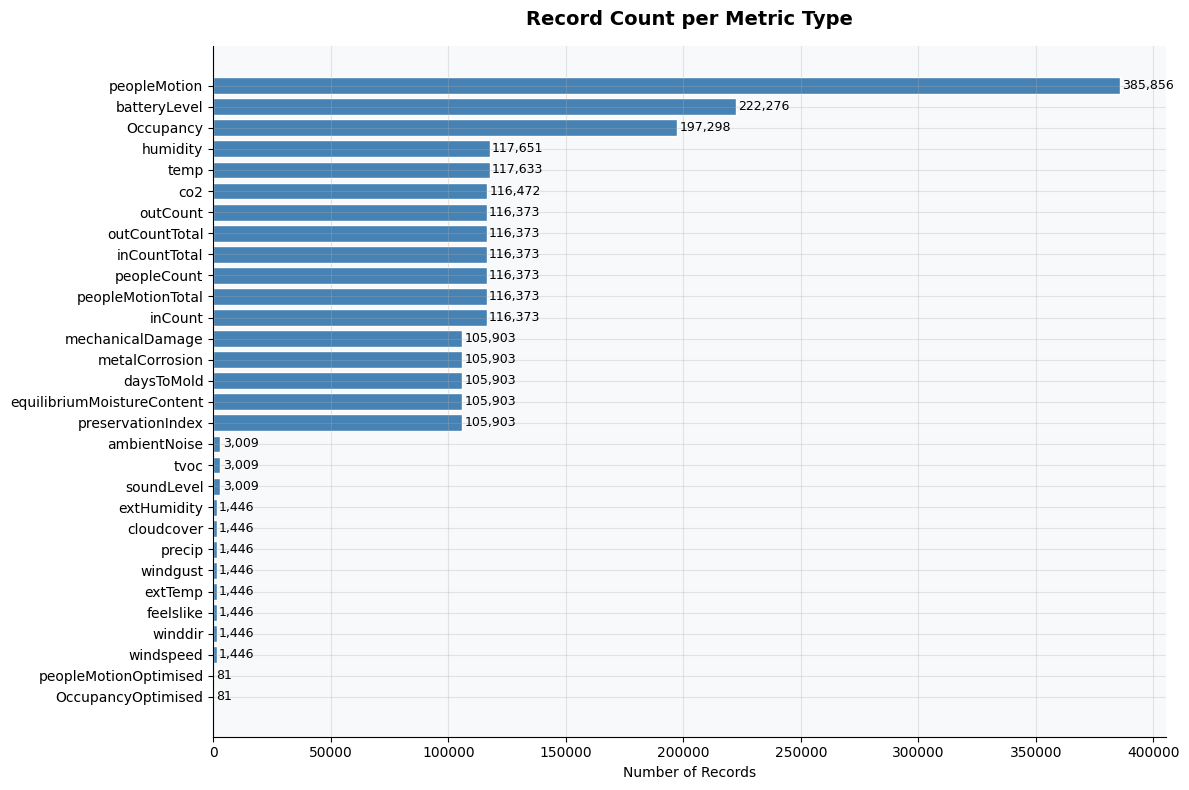

In [68]:
metric_counts = df['metric_name'].value_counts()

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(metric_counts.index, metric_counts.values, color='steelblue', edgecolor='white')
for bar, val in zip(bars, metric_counts.values):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.set_title('Record Count per Metric Type', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Records')
ax.invert_yaxis()
plt.tight_layout(); plt.show()

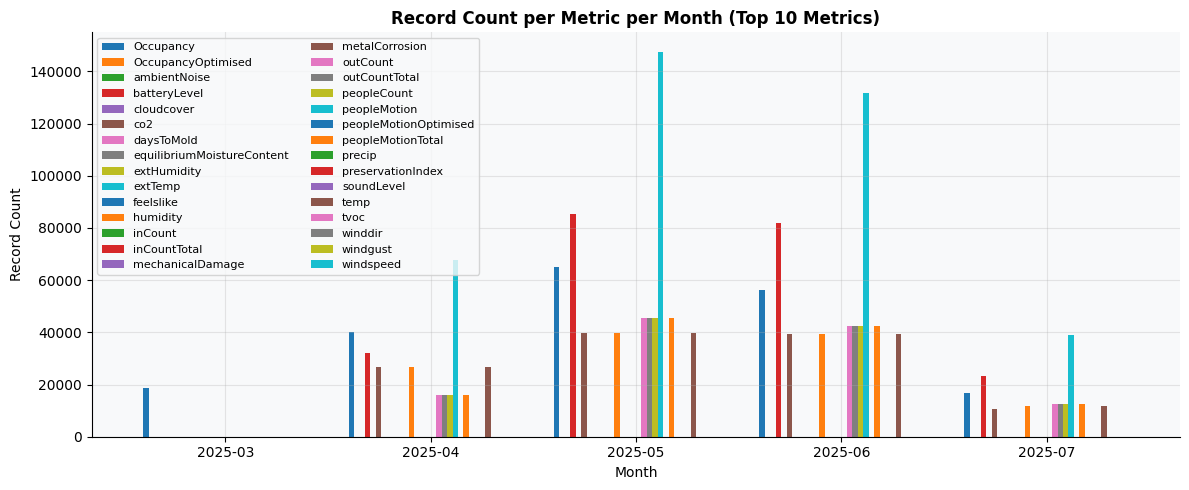

In [69]:

df_merged['month'] = df_merged['start_time'].dt.to_period('M').astype(str)

top_metrics = df_merged['metric_name'].value_counts().head(10).index
coverage = (df_merged[df_merged['metric_name'].isin(top_metrics)]
            .groupby(['month', 'metric_name'])
            .size()
            .unstack(fill_value=0))

fig, ax = plt.subplots(figsize=(12, 5))
coverage.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Record Count per Metric per Month (Top 10 Metrics)', fontsize=12, fontweight='bold')
ax.set_xlabel('Month'); ax.set_ylabel('Record Count')
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

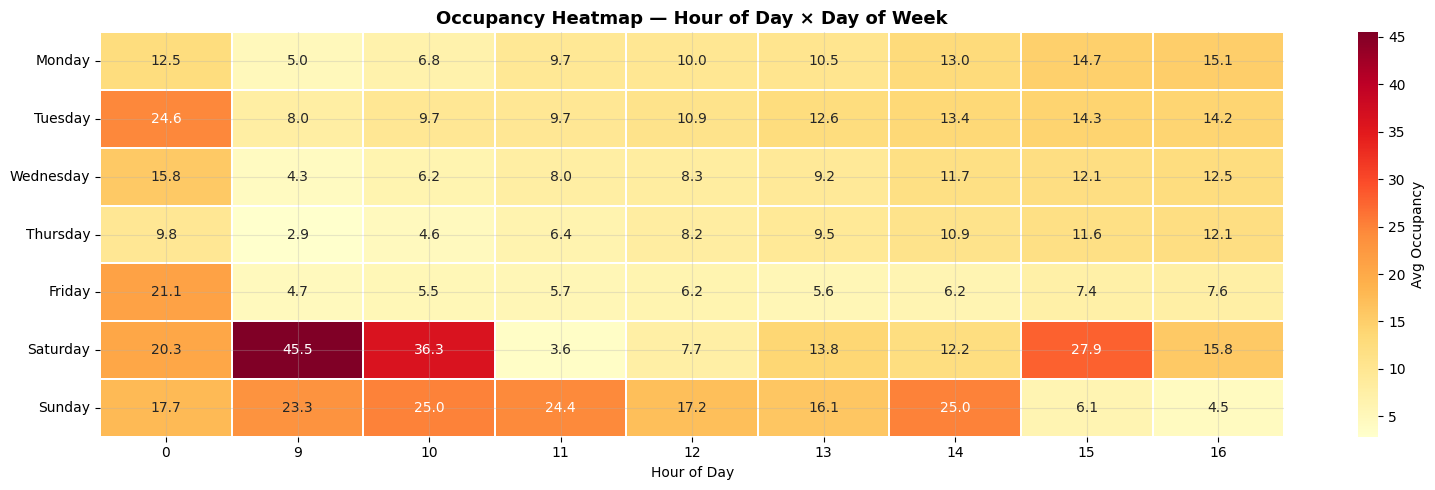

In [70]:
occ2 = occ.copy()
occ2['start_time'] = pd.to_datetime(
    occ2['start_time'],
    errors='coerce',
    utc=True
)
occ2 = occ2.dropna(subset=['start_time'])
occ2['hour'] = occ2['start_time'].dt.hour
occ2['weekday'] = occ2['start_time'].dt.day_name()
pivot = (
    occ2.groupby(['weekday', 'hour'])['value']
    .mean()
    .unstack()
    .reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
)
fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    pivot,
    cmap='YlOrRd',
    annot=True,
    fmt='.1f',
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Avg Occupancy'},
    ax=ax
)
ax.set_title('Occupancy Heatmap — Hour of Day × Day of Week', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

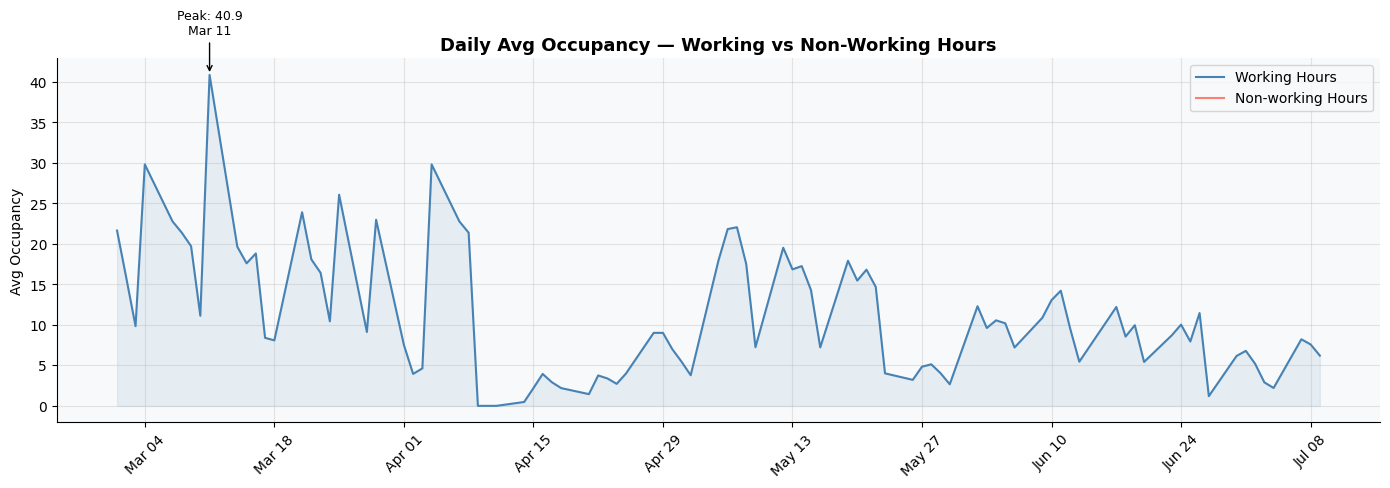

In [71]:
occ_daily = occ.copy()
occ_daily['start_time'] = pd.to_datetime(
    occ_daily['start_time'],
    errors='coerce',
    utc=True
)
occ_daily = occ_daily.dropna(subset=['start_time'])
occ_daily['date'] = occ_daily['start_time'].dt.date
occ_daily = (
    occ_daily.groupby(['date', 'is_working'])['value']
    .mean()
    .reset_index()
)
occ_daily['date'] = pd.to_datetime(occ_daily['date'])
fig, ax = plt.subplots(figsize=(14, 5))
for flag, color, label in [
    (True, 'steelblue', 'Working Hours'),
    (False, 'salmon', 'Non-working Hours')
]:
    d = occ_daily[occ_daily['is_working'] == flag]
    ax.plot(d['date'], d['value'], color=color, linewidth=1.5, label=label)
    ax.fill_between(d['date'], d['value'], alpha=0.1, color=color)
peak = occ_daily[occ_daily['is_working'] == True].sort_values('value', ascending=False).iloc[0]
ax.annotate(
    f"Peak: {peak['value']:.1f}\n{peak['date'].strftime('%b %d')}",
    xy=(peak['date'], peak['value']),
    xytext=(peak['date'], peak['value'] + 5),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=9,
    ha='center'
)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=45)
ax.set_title('Daily Avg Occupancy — Working vs Non-Working Hours', fontsize=13, fontweight='bold')
ax.set_ylabel('Avg Occupancy')
ax.legend()
plt.tight_layout()
plt.show()

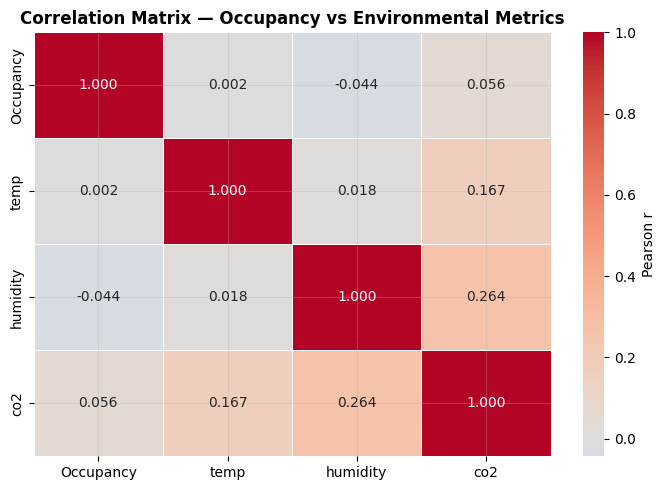

In [72]:
corr_metrics = ['Occupancy', 'temp', 'humidity', 'co2']
corr_dfs = []

for m in corr_metrics:
    tmp = df[(df['metric_name']==m) & (df['aggregation']=='mean')][
        ['geometry_id','start_time','value']
    ].rename(columns={'value': m})
    corr_dfs.append(tmp)
from functools import reduce
corr_df = reduce(lambda a,b: pd.merge(a, b, on=['geometry_id','start_time'], how='inner'), corr_dfs)

corr_matrix = corr_df[corr_metrics].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = pd.DataFrame(False, index=corr_matrix.index, columns=corr_matrix.columns)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5, mask=mask,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlation Matrix — Occupancy vs Environmental Metrics', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# **Feature engineering**

In [73]:
df_fe = df_merged[df_merged['in_hierarchy'] == True].copy()
print(f"Working dataset: {len(df_fe):,} rows, {df_fe['geometry_id'].nunique()} rooms")
occ = df_fe[
    (df_fe['metric_name'] == 'Occupancy') &
    (df_fe['aggregation'] == 'mean')
][['geometry_id', 'display_name', 'start_time', 'value',
   'is_working', 'is_holiday']].copy()

occ = occ.rename(columns={'value': 'occupancy'})
occ = occ.sort_values(['geometry_id', 'start_time']).reset_index(drop=True)
print(f"Occupancy rows: {len(occ):,}")

Working dataset: 1,386,691 rows, 32 rooms
Occupancy rows: 58,098


In [74]:
occ['hour']        = occ['start_time'].dt.hour
occ['day_of_week'] = occ['start_time'].dt.dayofweek
occ['month']       = occ['start_time'].dt.month
occ['is_weekend']  = (occ['day_of_week'] >= 5).astype(int)
occ['is_holiday']  = occ['is_holiday'].astype(int)
occ['is_working']  = occ['is_working'].astype(int)
occ = occ.sort_values(['geometry_id', 'start_time'])
occ['occ_lag_1h']   = occ.groupby('geometry_id')['occupancy'].shift(1)
occ['occ_lag_24h']  = occ.groupby('geometry_id')['occupancy'].shift(24)
occ['occ_lag_168h'] = occ.groupby('geometry_id')['occupancy'].shift(168)
occ['occ_roll_3h']  = (occ.groupby('geometry_id')['occupancy']
                          .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean()))
occ['occ_roll_24h'] = (occ.groupby('geometry_id')['occupancy']
                          .transform(lambda x: x.shift(1).rolling(24, min_periods=1).mean()))
print("Lag + rolling features added")
print(occ[['geometry_id','start_time','occupancy','occ_lag_1h','occ_lag_24h','occ_roll_3h']].head(10))

Lag + rolling features added
   geometry_id                start_time  occupancy  occ_lag_1h  occ_lag_24h  \
0        23595 2025-04-09 11:00:00+00:00        0.0         NaN          NaN   
1        23595 2025-04-09 12:00:00+00:00        0.0         0.0          NaN   
2        23595 2025-04-09 13:00:00+00:00        0.0         0.0          NaN   
3        23595 2025-04-09 14:00:00+00:00        0.0         0.0          NaN   
4        23595 2025-04-09 15:00:00+00:00        0.0         0.0          NaN   
5        23595 2025-04-09 16:00:00+00:00        0.0         0.0          NaN   
6        23595 2025-04-09 17:00:00+00:00        0.0         0.0          NaN   
7        23595 2025-04-09 18:00:00+00:00        0.0         0.0          NaN   
8        23595 2025-04-09 19:00:00+00:00        0.0         0.0          NaN   
9        23595 2025-04-09 20:00:00+00:00        0.0         0.0          NaN   

   occ_roll_3h  
0          NaN  
1          0.0  
2          0.0  
3          0.0  
4    

In [75]:
room_baseline = occ.groupby('geometry_id')['occupancy'].mean().rename('room_baseline')
occ = occ.merge(room_baseline, on='geometry_id', how='left')
occ['occ_vs_baseline'] = occ['occupancy'] - occ['room_baseline']
print("Room baseline added")

Room baseline added


In [76]:

env_metrics = ['temp', 'co2', 'humidity']
env_frames = []
for metric in env_metrics:
    tmp = df_fe[
        (df_fe['metric_name'] == metric) &
        (df_fe['aggregation'] == 'mean')
    ][['geometry_id', 'start_time', 'value']].copy()
    tmp = tmp.rename(columns={'value': metric})
    env_frames.append(tmp)

from functools import reduce
env_combined = reduce(
    lambda a, b: pd.merge(a, b, on=['geometry_id', 'start_time'], how='outer'),
    env_frames
)
occ = occ.merge(env_combined, on=['geometry_id', 'start_time'], how='left')
print(f"After env join: {occ.shape}")
print(f"Temp null %   : {occ['temp'].isna().mean()*100:.1f}%")
print(f"CO2 null %    : {occ['co2'].isna().mean()*100:.1f}%")

After env join: (58098, 20)
Temp null %   : 45.6%
CO2 null %    : 46.3%


In [77]:

weather_metrics = ['extTemp', 'extHumidity', 'windspeed', 'cloudcover']
weather_frames  = []
for metric in weather_metrics:
    tmp = df_merged[
        (df_merged['metric_name'] == metric) &
        (df_merged['aggregation'] == 'mean')
    ][['start_time', 'value']].copy()
    tmp = tmp.groupby('start_time')['value'].mean().reset_index()
    tmp = tmp.rename(columns={'value': metric})
    weather_frames.append(tmp)

weather = reduce(
    lambda a, b: pd.merge(a, b, on='start_time', how='outer'),
    weather_frames
)
occ = occ.merge(weather, on='start_time', how='left')
print(f"Weather features added. Shape: {occ.shape}")

Weather features added. Shape: (58098, 24)


In [78]:

occ['co2_high']      = (occ['co2'] > 1000).astype(float)   # ventilation concern
occ['temp_above_21'] = (occ['temp'] > 21).astype(float)    # overheating flag

feature_cols = [
    'hour', 'day_of_week', 'month', 'is_weekend', 'is_holiday', 'is_working',
    'occ_lag_1h', 'occ_lag_24h', 'occ_lag_168h',
    'occ_roll_3h', 'occ_roll_24h',
    'room_baseline', 'occ_vs_baseline',
    'temp', 'co2', 'humidity',
    'extTemp', 'extHumidity', 'windspeed', 'cloudcover',
    'co2_high', 'temp_above_21'
]

occ_clean = occ.dropna(subset=['occ_lag_1h', 'occ_lag_24h']).copy()

for col in ['temp', 'co2', 'humidity', 'extTemp', 'extHumidity', 'windspeed', 'cloudcover']:
    occ_clean[col] = occ_clean[col].fillna(occ_clean[col].median())

occ_clean['co2_high']      = (occ_clean['co2'] > 1000).astype(float)
occ_clean['temp_above_21'] = (occ_clean['temp'] > 21).astype(float)

print(f"\nFinal feature dataset: {occ_clean.shape}")
print(f"Null values left     : {occ_clean[feature_cols].isnull().sum().sum()}")
print(f"Rooms                : {occ_clean['geometry_id'].nunique()}")
print(f"Date range           : {occ_clean['start_time'].min()} → {occ_clean['start_time'].max()}")
occ_clean[feature_cols + ['occupancy']].describe()


Final feature dataset: (57354, 26)
Null values left     : 4364
Rooms                : 31
Date range           : 2025-03-02 00:00:00+00:00 → 2025-07-09 13:00:00+00:00


,hour,day_of_week,month,is_weekend,is_holiday,is_working,occ_lag_1h,occ_lag_24h,occ_lag_168h,occ_roll_3h,...,temp,co2,humidity,extTemp,extHumidity,windspeed,cloudcover,co2_high,temp_above_21,occupancy
count,57354.000000,57354.000000,57354.000000,57354.000000,57354.0,57354.000000,57354.000000,57354.000000,52990.000000,57354.000000,...,57354.000000,57354.000000,57354.000000,57354.000000,57354.000000,57354.000000,57354.000000,57354.000000,57354.000000,57354.000000
mean,11.579872,2.937354,5.221048,0.270077,0.0,0.246051,4.069563,4.028660,4.120034,4.063894,...,21.791835,453.966389,48.829504,13.267310,64.579928,9.814220,53.213396,0.020434,0.804652,4.075833
std,6.922108,1.985273,1.052984,0.444003,0.0,0.430712,17.706273,17.540725,17.680951,16.574889,...,1.500400,155.431954,5.666730,2.403609,8.410774,2.276687,16.531999,0.141482,0.396472,17.716711
min,0.000000,0.000000,3.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,13.833333,380.000000,19.500000,3.800000,26.390000,1.100000,0.000000,0.000000,0.000000,0.000000
25%,6.000000,1.000000,5.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,21.475000,406.000000,48.000000,13.200000,64.670000,9.700000,54.200000,0.000000,1.000000,0.000000
50%,12.000000,3.000000,5.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,21.700000,419.333333,49.000000,13.200000,64.670000,9.700000,54.200000,0.000000,1.000000,0.000000
75%,18.000000,5.000000,6.000000,1.000000,0.0,0.000000,0.083333,0.000000,0.083333,0.505556,...,21.900000,427.666667,50.000000,13.200000,64.670000,9.700000,54.200000,0.000000,1.000000,0.083333
max,23.000000,6.000000,7.000000,1.000000,0.0,1.000000,428.916667,428.916667,428.916667,380.111111,...,34.800000,4056.666667,72.000000,27.000000,95.340000,23.000000,100.000000,1.000000,1.000000,428.916667


In [79]:
occ_clean['occ_lag_168h'] = occ_clean['occ_lag_168h'].fillna(occ_clean['occ_lag_24h'])
print(f"Nulls left: {occ_clean[feature_cols].isnull().sum().sum()}")

Nulls left: 0


# **Train/Test Split + Two Regression Models**

In [80]:
SPLIT_DATE = pd.Timestamp('2025-07-01', tz='UTC')

train = occ_clean[occ_clean['start_time'] <  SPLIT_DATE]
test  = occ_clean[occ_clean['start_time'] >= SPLIT_DATE]

print(f"Train : {len(train):,} rows")
print(f"Test  : {len(test):,}  rows")
print(f"Train date range: {train['start_time'].min().date()} → {train['start_time'].max().date()}")
print(f"Test  date range: {test['start_time'].min().date()}  → {test['start_time'].max().date()}")

X_train = train[feature_cols]
y_train = train['occupancy']

X_test  = test[feature_cols]
y_test  = test['occupancy']

print(f"\nX_train shape : {X_train.shape}")
print(f"X_test  shape : {X_test.shape}")

Train : 51,786 rows
Test  : 5,568  rows
Train date range: 2025-03-02 → 2025-06-30
Test  date range: 2025-07-01  → 2025-07-09

X_train shape : (51786, 22)
X_test  shape : (5568, 22)


In [81]:
def evaluate(model_name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    print(f"\n{'─'*35}")
    print(f"  {model_name}")
    print(f"{'─'*35}")
    print(f"  MAE  : {mae:.3f}   (avg prediction error)")
    print(f"  RMSE : {rmse:.3f}  (penalises big errors)")
    print(f"  R²   : {r2:.3f}   (1.0 = perfect fit)")

    return {'Model': model_name, 'MAE': round(mae,3),
            'RMSE': round(rmse,3), 'R2': round(r2,3)}

In [82]:
print("Training Random Forest...")

rf = RandomForestRegressor(
    n_estimators  = 100,
    max_depth     = 10,
    min_samples_leaf = 5,
    random_state  = 42,
    n_jobs        = -1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_results = evaluate("Random Forest", y_test, rf_pred)

Training Random Forest...

───────────────────────────────────
  Random Forest
───────────────────────────────────
  MAE  : 0.141   (avg prediction error)
  RMSE : 0.617  (penalises big errors)
  R²   : 0.998   (1.0 = perfect fit)


In [83]:
print("Training XGBoost...")

xgb = XGBRegressor(
    n_estimators  = 200,
    max_depth     = 5,
    learning_rate = 0.05,
    subsample     = 0.8,
    random_state  = 42,
    n_jobs        = -1,
    verbosity     = 0
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

xgb_results = evaluate("XGBoost", y_test, xgb_pred)

Training XGBoost...

───────────────────────────────────
  XGBoost
───────────────────────────────────
  MAE  : 0.254   (avg prediction error)
  RMSE : 1.076  (penalises big errors)
  R²   : 0.995   (1.0 = perfect fit)


In [40]:
results_df = pd.DataFrame([rf_results, xgb_results])
print("\n")
print(results_df.to_string(index=False))
best = results_df.loc[results_df['R2'].idxmax(), 'Model']
print(f"\n Best model by R² : {best}")



        Model   MAE  RMSE    R2
Random Forest 0.141 0.617 0.998
      XGBoost 0.254 1.076 0.995

 Best model by R² : Random Forest


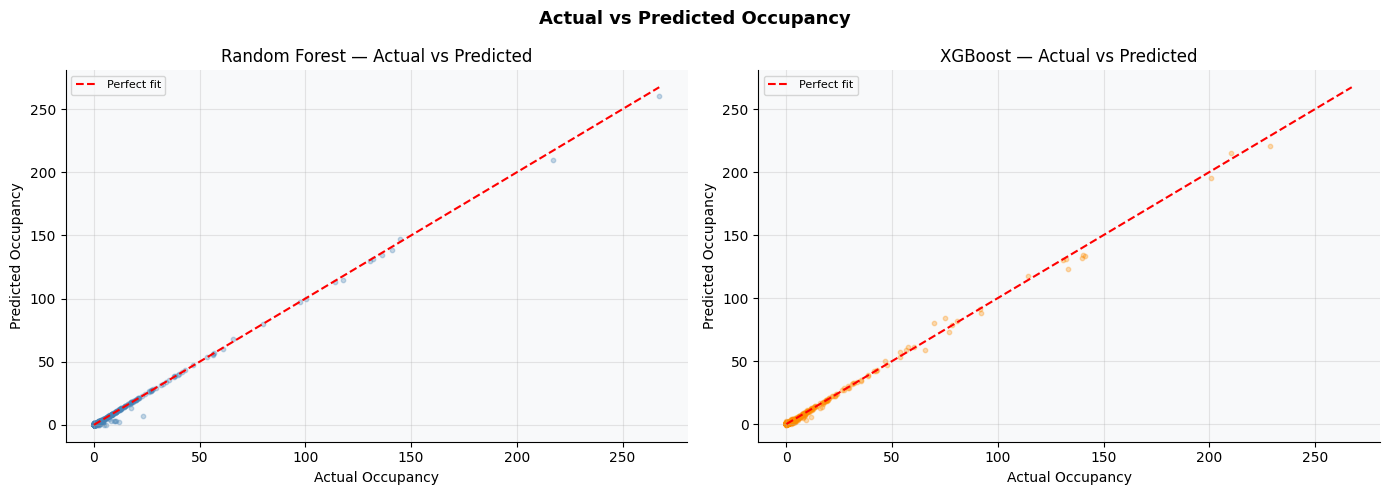

In [41]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, name, color in zip(
    axes,
    [rf_pred, xgb_pred],
    ['Random Forest', 'XGBoost'],
    ['steelblue', 'darkorange']
):

    idx = np.random.choice(len(y_test), size=min(1500, len(y_test)), replace=False)

    ax.scatter(
        y_test.values[idx], preds[idx],
        alpha=0.3, s=10, color=color
    )

    max_val = max(y_test.max(), preds.max())
    ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect fit')

    ax.set_xlabel('Actual Occupancy')
    ax.set_ylabel('Predicted Occupancy')
    ax.set_title(f'{name} — Actual vs Predicted')
    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted Occupancy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

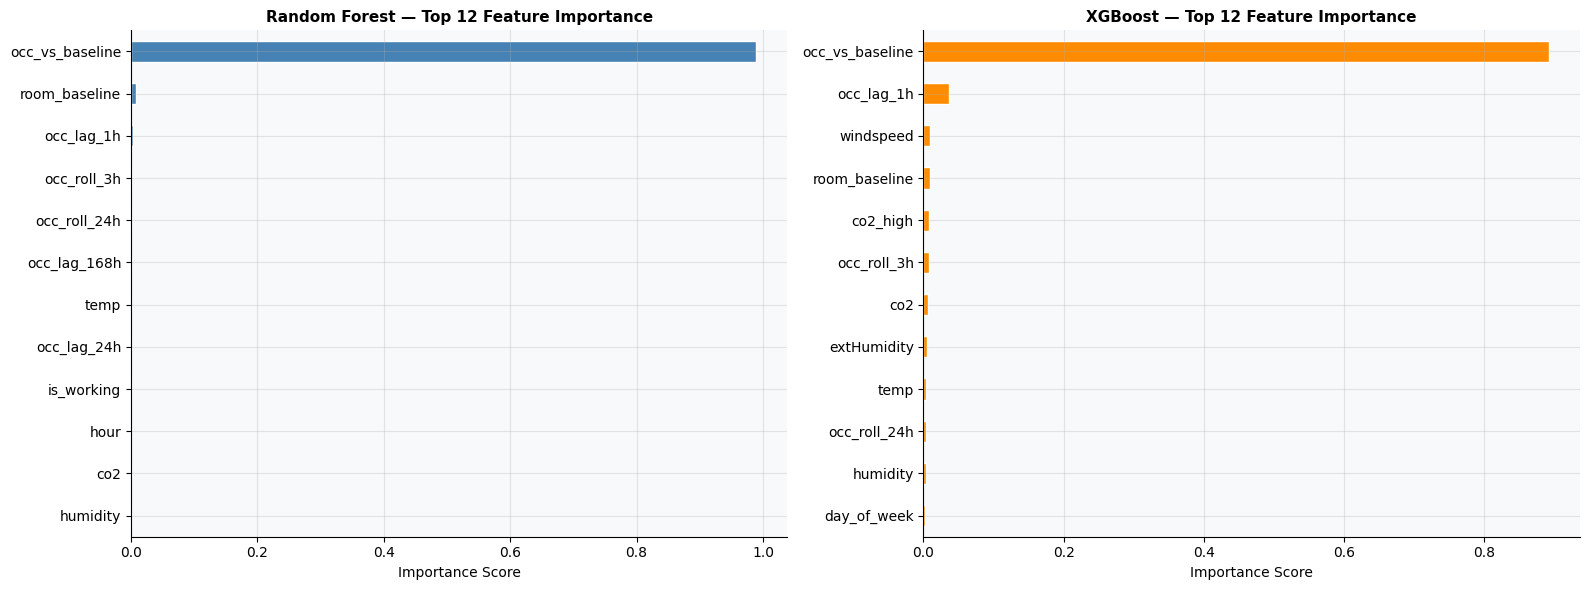

In [42]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model, name, color in zip(
    axes,
    [rf, xgb],
    ['Random Forest', 'XGBoost'],
    ['steelblue', 'darkorange']
):
    imp = pd.Series(model.feature_importances_, index=feature_cols)
    imp = imp.sort_values(ascending=True).tail(12)  # top 12 features

    imp.plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(f'{name} — Top 12 Feature Importance', fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

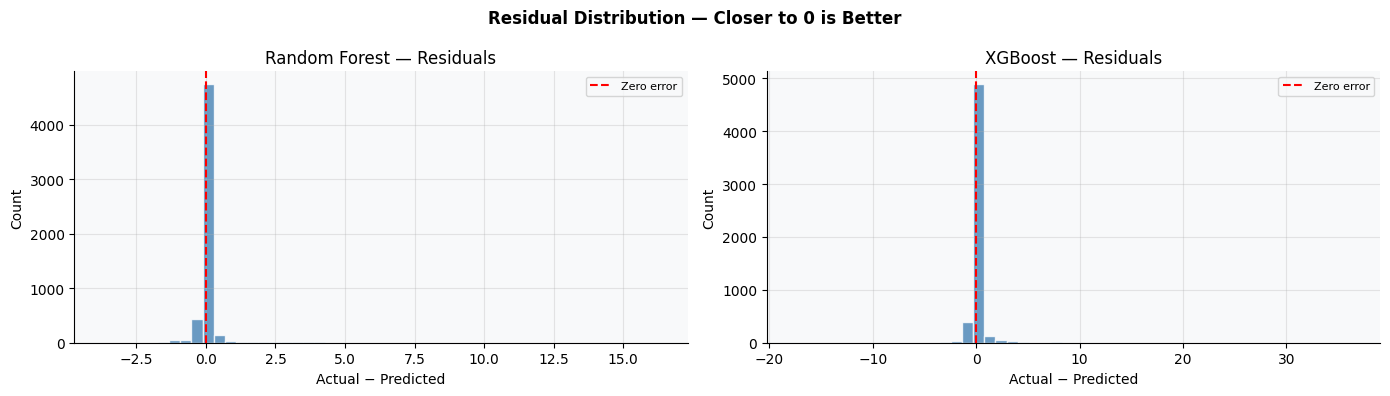

In [43]:
# ── PLOT 3: Residuals ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, preds, name in zip(
    axes,
    [rf_pred, xgb_pred],
    ['Random Forest', 'XGBoost']
):
    residuals = y_test.values - preds

    ax.hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
    ax.set_title(f'{name} — Residuals')
    ax.set_xlabel('Actual − Predicted')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle('Residual Distribution — Closer to 0 is Better',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

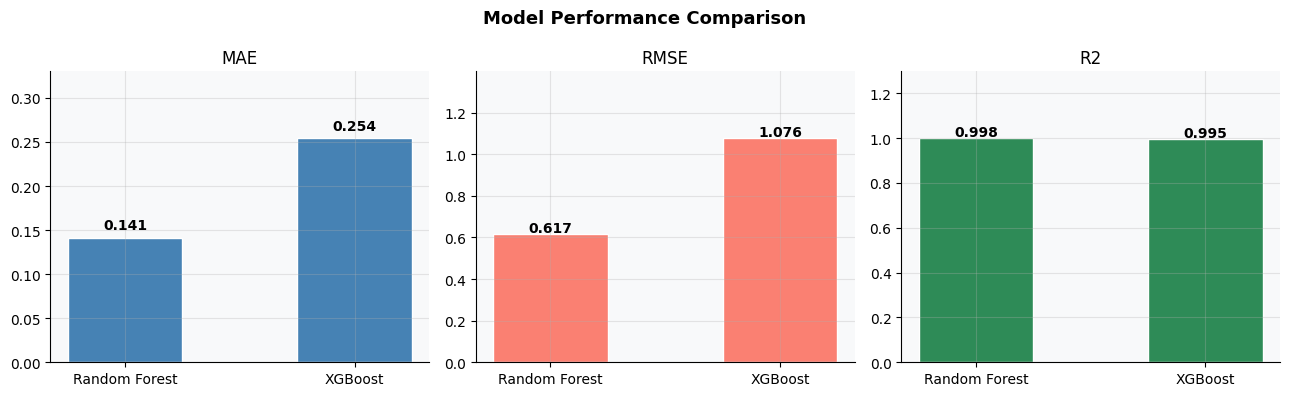

In [44]:
# ── PLOT 4: Bar chart — Model Metrics Comparison ──────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, metric, color in zip(axes, ['MAE', 'RMSE', 'R2'],
                              ['steelblue', 'salmon', 'seagreen']):
    bars = ax.bar(results_df['Model'], results_df[metric],
                  color=color, edgecolor='white', width=0.5)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_title(metric)
    ax.set_ylim(0, results_df[metric].max() * 1.3)

plt.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [45]:
# ── SAVE MODELS ───────────────────────────────────────────────
import joblib

joblib.dump(rf,  'rf_model.pkl')
joblib.dump(xgb, 'xgb_model.pkl')

occ_clean.to_parquet('occ_features.parquet', index=False)

print("Saved:")
print("  rf_model.pkl")
print("  xgb_model.pkl")
print("  occ_features.parquet")

Saved:
  rf_model.pkl
  xgb_model.pkl
  occ_features.parquet


# **Integrated Chatbot with Dashboard**

In [46]:
df = occ_clean.copy()
df['date'] = df['start_time'].dt.date
df['hour'] = df['start_time'].dt.hour

In [88]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import joblib
import re
from groq import Groq

# ── Page Config ──────────────────────────────────────────────
st.set_page_config(
    page_title="PES Building Dashboard",
    page_icon="🏢",
    layout="wide"
)

# ── Google Fonts + 3D Gradient Background + Custom CSS ───────
st.markdown("""
<link href="https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700;800;900&family=Space+Grotesk:wght@300;400;500;600;700&family=JetBrains+Mono:wght@400;500&display=swap" rel="stylesheet">

<style>
/* ═══════════════════════════════════════════════════════════
   ROOT & ANIMATED 3D GRADIENT BACKGROUND
═══════════════════════════════════════════════════════════ */
:root {
    --grad-1: #0f0c29;
    --grad-2: #1a1a4e;
    --grad-3: #0d1b4b;
    --grad-4: #162447;
    --accent:  #6c63ff;
    --accent2: #00d4ff;
    --accent3: #ff6b9d;
    --accent4: #43e97b;
    --glass:   rgba(255,255,255,0.05);
    --glass-b: rgba(255,255,255,0.10);
    --text:    #e8eaf6;
    --sub:     #9fa8da;
    --card-bg: rgba(15,20,60,0.70);
}

/* animated 3-layer gradient */
@keyframes gradShift {
    0%   { background-position: 0% 50%; }
    50%  { background-position: 100% 50%; }
    100% { background-position: 0% 50%; }
}

/* floating orbs */
@keyframes float1 {
    0%, 100% { transform: translate(0px, 0px) scale(1); }
    33%       { transform: translate(40px, -60px) scale(1.08); }
    66%       { transform: translate(-30px, 30px) scale(0.95); }
}
@keyframes float2 {
    0%, 100% { transform: translate(0px, 0px) scale(1); }
    33%       { transform: translate(-50px, 40px) scale(1.12); }
    66%       { transform: translate(30px, -50px) scale(0.92); }
}
@keyframes float3 {
    0%, 100% { transform: translate(0px, 0px) scale(1); }
    50%       { transform: translate(60px, 60px) scale(1.05); }
}

.stApp {
    background: linear-gradient(
        135deg,
        #0f0c29 0%,
        #1a0a3e 15%,
        #0d1b4b 30%,
        #0a2a6e 45%,
        #0d3b6e 55%,
        #0a1f4e 70%,
        #1a0a3e 85%,
        #0f0c29 100%
    );
    background-size: 400% 400%;
    animation: gradShift 18s ease infinite;
    min-height: 100vh;
    font-family: 'Inter', sans-serif;
    color: var(--text);
}

/* pseudo-element orbs for depth */
.stApp::before {
    content: '';
    position: fixed;
    top: -20%;
    left: -15%;
    width: 55vw;
    height: 55vw;
    border-radius: 50%;
    background: radial-gradient(circle, rgba(108,99,255,0.18) 0%, transparent 70%);
    animation: float1 12s ease-in-out infinite;
    pointer-events: none;
    z-index: 0;
}
.stApp::after {
    content: '';
    position: fixed;
    bottom: -20%;
    right: -15%;
    width: 60vw;
    height: 60vw;
    border-radius: 50%;
    background: radial-gradient(circle, rgba(0,212,255,0.14) 0%, transparent 70%);
    animation: float2 15s ease-in-out infinite;
    pointer-events: none;
    z-index: 0;
}

/* third orb via a wrapper trick */
[data-testid="stAppViewContainer"]::before {
    content: '';
    position: fixed;
    top: 40%;
    left: 40%;
    width: 40vw;
    height: 40vw;
    border-radius: 50%;
    background: radial-gradient(circle, rgba(255,107,157,0.10) 0%, transparent 70%);
    animation: float3 20s ease-in-out infinite;
    pointer-events: none;
    z-index: 0;
}

/* ═══════════════════════════════════════════════════════════
   MAIN CONTENT WRAPPER
═══════════════════════════════════════════════════════════ */
[data-testid="stAppViewContainer"] > .main {
    background: transparent;
    position: relative;
    z-index: 1;
}

[data-testid="block-container"] {
    padding: 2rem 3rem 4rem 3rem;
}

/* ═══════════════════════════════════════════════════════════
   SIDEBAR
═══════════════════════════════════════════════════════════ */
[data-testid="stSidebar"] {
    background: rgba(10, 12, 40, 0.85) !important;
    backdrop-filter: blur(20px);
    border-right: 1px solid rgba(108,99,255,0.25);
}

/* ═══════════════════════════════════════════════════════════
   HEADER TITLE
═══════════════════════════════════════════════════════════ */
h1 {
    font-family: 'Space Grotesk', sans-serif !important;
    font-weight: 800 !important;
    font-size: 2.6rem !important;
    background: linear-gradient(135deg, #ffffff 0%, #a78bfa 40%, #00d4ff 80%, #43e97b 100%);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    background-clip: text;
    letter-spacing: -0.5px;
    margin-bottom: 0 !important;
}

h2 {
    font-family: 'Space Grotesk', sans-serif !important;
    font-weight: 700 !important;
    color: #c7d2fe !important;
    font-size: 1.25rem !important;
    letter-spacing: -0.2px;
}

h3 {
    font-family: 'Space Grotesk', sans-serif !important;
    font-weight: 600 !important;
    color: #e0e7ff !important;
    font-size: 1.05rem !important;
}

p, li, span, div {
    font-family: 'Inter', sans-serif;
    color: var(--text);
}

/* ═══════════════════════════════════════════════════════════
   CAPTION
═══════════════════════════════════════════════════════════ */
[data-testid="stCaptionContainer"] p,
.stCaption p {
    font-family: 'Inter', sans-serif !important;
    color: var(--sub) !important;
    font-size: 0.82rem !important;
    font-weight: 400;
}

/* ═══════════════════════════════════════════════════════════
   DIVIDER
═══════════════════════════════════════════════════════════ */
hr {
    border: none !important;
    height: 1px !important;
    background: linear-gradient(90deg, transparent, rgba(108,99,255,0.5), rgba(0,212,255,0.5), transparent) !important;
    margin: 1.5rem 0 !important;
}

/* ═══════════════════════════════════════════════════════════
   KPI METRIC CARDS — glassmorphism
═══════════════════════════════════════════════════════════ */
[data-testid="stMetric"] {
    background: linear-gradient(135deg, rgba(108,99,255,0.12), rgba(0,212,255,0.08)) !important;
    border: 1px solid rgba(108,99,255,0.30) !important;
    border-radius: 18px !important;
    padding: 1.4rem 1.6rem !important;
    backdrop-filter: blur(16px) !important;
    box-shadow:
        0 8px 32px rgba(0,0,0,0.35),
        0 0 0 1px rgba(255,255,255,0.04) inset,
        0 1px 0 rgba(255,255,255,0.10) inset !important;
    transition: transform 0.25s ease, box-shadow 0.25s ease !important;
    position: relative;
    overflow: hidden;
}

[data-testid="stMetric"]::before {
    content: '';
    position: absolute;
    top: 0; left: 0; right: 0;
    height: 2px;
    background: linear-gradient(90deg, #6c63ff, #00d4ff, #43e97b);
    border-radius: 18px 18px 0 0;
}

[data-testid="stMetric"]:hover {
    transform: translateY(-4px) !important;
    box-shadow:
        0 20px 50px rgba(108,99,255,0.25),
        0 0 0 1px rgba(108,99,255,0.40) inset !important;
}

[data-testid="stMetricLabel"] p {
    font-family: 'Space Grotesk', sans-serif !important;
    font-weight: 600 !important;
    font-size: 0.80rem !important;
    color: #9fa8da !important;
    text-transform: uppercase;
    letter-spacing: 0.8px;
}

[data-testid="stMetricValue"] {
    font-family: 'Space Grotesk', sans-serif !important;
    font-weight: 700 !important;
    font-size: 1.15rem !important;
    color: #ffffff !important;
}

[data-testid="stMetricDelta"] {
    font-family: 'JetBrains Mono', monospace !important;
    font-size: 0.82rem !important;
    color: #43e97b !important;
}

/* ═══════════════════════════════════════════════════════════
   TABS
═══════════════════════════════════════════════════════════ */
[data-testid="stTabs"] {
    background: transparent !important;
}

[data-testid="stTabBar"] {
    background: rgba(15,20,60,0.60) !important;
    backdrop-filter: blur(16px);
    border-radius: 14px !important;
    padding: 5px 6px !important;
    border: 1px solid rgba(108,99,255,0.20) !important;
    gap: 4px;
}

button[data-baseweb="tab"] {
    font-family: 'Space Grotesk', sans-serif !important;
    font-weight: 600 !important;
    font-size: 0.82rem !important;
    color: #9fa8da !important;
    border-radius: 10px !important;
    padding: 8px 16px !important;
    transition: all 0.22s ease !important;
    background: transparent !important;
    border: none !important;
}

button[data-baseweb="tab"]:hover {
    background: rgba(108,99,255,0.15) !important;
    color: #e8eaf6 !important;
}

button[data-baseweb="tab"][aria-selected="true"] {
    background: linear-gradient(135deg, rgba(108,99,255,0.50), rgba(0,212,255,0.30)) !important;
    color: #ffffff !important;
    box-shadow: 0 4px 15px rgba(108,99,255,0.30) !important;
}

/* ═══════════════════════════════════════════════════════════
   TAB CONTENT PANELS
═══════════════════════════════════════════════════════════ */
[data-testid="stTabsContent"] {
    background: rgba(15,20,60,0.45) !important;
    backdrop-filter: blur(20px);
    border-radius: 18px !important;
    border: 1px solid rgba(108,99,255,0.18) !important;
    padding: 1.8rem !important;
    margin-top: 8px !important;
    box-shadow:
        0 20px 60px rgba(0,0,0,0.40),
        0 0 0 1px rgba(255,255,255,0.03) inset !important;
}

/* ═══════════════════════════════════════════════════════════
   PLOTLY CHART CONTAINERS
═══════════════════════════════════════════════════════════ */
[data-testid="stPlotlyChart"] {
    background: rgba(10,14,45,0.55) !important;
    border-radius: 16px !important;
    border: 1px solid rgba(108,99,255,0.18) !important;
    padding: 8px !important;
    box-shadow: 0 8px 30px rgba(0,0,0,0.30) !important;
    overflow: hidden;
}

/* ═══════════════════════════════════════════════════════════
   SELECTBOX / INPUTS / SLIDERS
═══════════════════════════════════════════════════════════ */
[data-testid="stSelectbox"] > div,
[data-testid="stDateInput"] > div,
[data-testid="stSlider"] > div {
    background: rgba(15,20,60,0.60) !important;
    border-radius: 12px !important;
    border: 1px solid rgba(108,99,255,0.25) !important;
}

[data-testid="stSelectbox"] label,
[data-testid="stDateInput"] label,
[data-testid="stSlider"] label {
    font-family: 'Space Grotesk', sans-serif !important;
    font-weight: 600 !important;
    font-size: 0.82rem !important;
    color: #9fa8da !important;
    text-transform: uppercase;
    letter-spacing: 0.6px;
}

div[data-baseweb="select"] > div {
    background: rgba(15,20,60,0.70) !important;
    border: 1px solid rgba(108,99,255,0.30) !important;
    border-radius: 10px !important;
    color: #e8eaf6 !important;
    font-family: 'Inter', sans-serif !important;
}

/* ═══════════════════════════════════════════════════════════
   BUTTONS
═══════════════════════════════════════════════════════════ */
[data-testid="stButton"] button {
    font-family: 'Space Grotesk', sans-serif !important;
    font-weight: 600 !important;
    font-size: 0.80rem !important;
    background: linear-gradient(135deg, rgba(108,99,255,0.20), rgba(0,212,255,0.12)) !important;
    border: 1px solid rgba(108,99,255,0.35) !important;
    border-radius: 12px !important;
    color: #c7d2fe !important;
    padding: 10px 14px !important;
    transition: all 0.22s ease !important;
    text-align: left !important;
    backdrop-filter: blur(8px);
}

[data-testid="stButton"] button:hover {
    background: linear-gradient(135deg, rgba(108,99,255,0.45), rgba(0,212,255,0.25)) !important;
    border-color: rgba(108,99,255,0.65) !important;
    color: #ffffff !important;
    transform: translateY(-2px) !important;
    box-shadow: 0 8px 24px rgba(108,99,255,0.30) !important;
}

[data-testid="stButton"] button:active {
    transform: translateY(0px) !important;
}

/* ═══════════════════════════════════════════════════════════
   DATAFRAME
═══════════════════════════════════════════════════════════ */
[data-testid="stDataFrame"] {
    border-radius: 14px !important;
    overflow: hidden !important;
    border: 1px solid rgba(108,99,255,0.22) !important;
    box-shadow: 0 8px 28px rgba(0,0,0,0.30) !important;
}

[data-testid="stDataFrame"] iframe {
    background: rgba(10,14,45,0.80) !important;
    border-radius: 14px !important;
}

/* ═══════════════════════════════════════════════════════════
   CHAT INTERFACE
═══════════════════════════════════════════════════════════ */
[data-testid="stChatMessage"] {
    background: rgba(15,20,60,0.55) !important;
    border-radius: 16px !important;
    border: 1px solid rgba(108,99,255,0.18) !important;
    backdrop-filter: blur(16px);
    margin: 8px 0 !important;
    padding: 4px !important;
    box-shadow: 0 4px 20px rgba(0,0,0,0.25) !important;
}

[data-testid="stChatMessage"][data-testid*="user"] {
    border-color: rgba(0,212,255,0.22) !important;
    background: rgba(0,50,80,0.45) !important;
}

[data-testid="stChatInputContainer"] {
    background: rgba(10,14,45,0.70) !important;
    border: 1px solid rgba(108,99,255,0.30) !important;
    border-radius: 16px !important;
    backdrop-filter: blur(16px);
    box-shadow: 0 8px 32px rgba(0,0,0,0.30) !important;
}

[data-testid="stChatInputContainer"] textarea {
    background: transparent !important;
    color: #e8eaf6 !important;
    font-family: 'Inter', sans-serif !important;
    font-size: 0.90rem !important;
}

[data-testid="stChatInputContainer"] button {
    background: linear-gradient(135deg, #6c63ff, #00d4ff) !important;
    border-radius: 10px !important;
    border: none !important;
}

/* ═══════════════════════════════════════════════════════════
   SPINNER
═══════════════════════════════════════════════════════════ */
[data-testid="stSpinner"] {
    color: #6c63ff !important;
}

/* ═══════════════════════════════════════════════════════════
   WARNING / INFO / SUCCESS BOXES
═══════════════════════════════════════════════════════════ */
[data-testid="stAlert"] {
    border-radius: 12px !important;
    border-left-width: 4px !important;
    backdrop-filter: blur(10px);
    background: rgba(15,20,60,0.60) !important;
    font-family: 'Inter', sans-serif !important;
}

/* ═══════════════════════════════════════════════════════════
   SCROLLBAR
═══════════════════════════════════════════════════════════ */
::-webkit-scrollbar { width: 6px; height: 6px; }
::-webkit-scrollbar-track { background: rgba(15,20,60,0.40); border-radius: 10px; }
::-webkit-scrollbar-thumb {
    background: linear-gradient(180deg, #6c63ff, #00d4ff);
    border-radius: 10px;
}
::-webkit-scrollbar-thumb:hover { background: linear-gradient(180deg, #8b85ff, #22e8ff); }

/* ═══════════════════════════════════════════════════════════
   MARKDOWN CODE BLOCKS
═══════════════════════════════════════════════════════════ */
code {
    font-family: 'JetBrains Mono', monospace !important;
    background: rgba(108,99,255,0.18) !important;
    color: #a78bfa !important;
    padding: 2px 7px !important;
    border-radius: 6px !important;
    font-size: 0.83rem !important;
}

/* ═══════════════════════════════════════════════════════════
   TABLES IN MARKDOWN (chatbot)
═══════════════════════════════════════════════════════════ */
table {
    font-family: 'Inter', sans-serif !important;
    border-collapse: collapse !important;
    width: 100% !important;
    border-radius: 10px;
    overflow: hidden;
}

th {
    background: rgba(108,99,255,0.25) !important;
    color: #c7d2fe !important;
    font-weight: 600 !important;
    font-size: 0.82rem !important;
    padding: 10px 14px !important;
    text-transform: uppercase;
    letter-spacing: 0.5px;
    border: 1px solid rgba(108,99,255,0.20) !important;
}

td {
    background: rgba(15,20,60,0.40) !important;
    color: #e8eaf6 !important;
    font-size: 0.85rem !important;
    padding: 9px 14px !important;
    border: 1px solid rgba(108,99,255,0.12) !important;
}

tr:hover td {
    background: rgba(108,99,255,0.12) !important;
}

/* ═══════════════════════════════════════════════════════════
   COLUMN CONTAINERS
═══════════════════════════════════════════════════════════ */
[data-testid="column"] {
    padding: 0 6px !important;
}

/* ═══════════════════════════════════════════════════════════
   SLIDER THUMB
═══════════════════════════════════════════════════════════ */
[data-baseweb="slider"] [data-testid="stThumbValue"] {
    font-family: 'JetBrains Mono', monospace !important;
    color: #a78bfa !important;
    font-size: 0.80rem !important;
}

/* ═══════════════════════════════════════════════════════════
   HIDE DEFAULT STREAMLIT ELEMENTS
═══════════════════════════════════════════════════════════ */
#MainMenu { visibility: hidden; }
footer    { visibility: hidden; }
header    { visibility: hidden; }

/* ═══════════════════════════════════════════════════════════
   CUSTOM HEADER BAR
═══════════════════════════════════════════════════════════ */
.custom-header {
    background: linear-gradient(135deg, rgba(108,99,255,0.15), rgba(0,212,255,0.08));
    border: 1px solid rgba(108,99,255,0.25);
    border-radius: 20px;
    padding: 1.5rem 2rem;
    margin-bottom: 1.5rem;
    backdrop-filter: blur(20px);
    box-shadow:
        0 8px 32px rgba(0,0,0,0.30),
        0 0 0 1px rgba(255,255,255,0.04) inset;
    position: relative;
    overflow: hidden;
}

.custom-header::before {
    content: '';
    position: absolute;
    top: 0; left: 0; right: 0;
    height: 2px;
    background: linear-gradient(90deg, #6c63ff, #00d4ff, #43e97b, #ff6b9d);
}

.header-title {
    font-family: 'Space Grotesk', sans-serif;
    font-weight: 800;
    font-size: 2.2rem;
    background: linear-gradient(135deg, #ffffff 0%, #a78bfa 35%, #00d4ff 70%, #43e97b 100%);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    background-clip: text;
    margin: 0;
    line-height: 1.2;
}

.header-sub {
    font-family: 'Inter', sans-serif;
    font-weight: 400;
    font-size: 0.88rem;
    color: #9fa8da;
    margin: 6px 0 0 0;
    letter-spacing: 0.3px;
}

.header-badge {
    display: inline-block;
    background: linear-gradient(135deg, rgba(108,99,255,0.30), rgba(0,212,255,0.20));
    border: 1px solid rgba(108,99,255,0.40);
    border-radius: 20px;
    padding: 4px 14px;
    font-family: 'Space Grotesk', sans-serif;
    font-size: 0.74rem;
    font-weight: 600;
    color: #a78bfa;
    letter-spacing: 0.5px;
    margin-top: 10px;
}

/* ═══════════════════════════════════════════════════════════
   SECTION SUBHEADER STYLE
═══════════════════════════════════════════════════════════ */
.section-header {
    font-family: 'Space Grotesk', sans-serif;
    font-weight: 700;
    font-size: 1.05rem;
    color: #c7d2fe;
    padding: 6px 0 12px 0;
    border-bottom: 1px solid rgba(108,99,255,0.20);
    margin-bottom: 16px;
    letter-spacing: -0.1px;
}

/* ═══════════════════════════════════════════════════════════
   QUICK QUESTION LABEL
═══════════════════════════════════════════════════════════ */
.quick-label {
    font-family: 'Space Grotesk', sans-serif;
    font-size: 0.78rem;
    font-weight: 600;
    color: #9fa8da;
    text-transform: uppercase;
    letter-spacing: 0.8px;
    margin-bottom: 8px;
}

</style>
""", unsafe_allow_html=True)

# ── Groq Setup ───────────────────────────────────────────────
groq_client = Groq(api_key="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")

# ── Load Data & Models ───────────────────────────────────────
@st.cache_data
def load_data():
    df = pd.read_parquet('occ_features.parquet')
    df['start_time'] = pd.to_datetime(df['start_time'], utc=True)
    df['date'] = df['start_time'].dt.date
    df['hour'] = df['start_time'].dt.hour
    return df

@st.cache_resource
def load_models():
    rf  = joblib.load('rf_model.pkl')
    xgb = joblib.load('xgb_model.pkl')
    return rf, xgb

df      = load_data()
rf, xgb = load_models()

FEATURE_COLS = [
    'hour', 'day_of_week', 'month', 'is_weekend', 'is_holiday', 'is_working',
    'occ_lag_1h', 'occ_lag_24h', 'occ_lag_168h',
    'occ_roll_3h', 'occ_roll_24h',
    'room_baseline', 'occ_vs_baseline',
    'temp', 'co2', 'humidity',
    'extTemp', 'extHumidity', 'windspeed', 'cloudcover',
    'co2_high', 'temp_above_21'
]

SPLIT_DATE = pd.Timestamp('2025-07-01', tz='UTC')

# ── Pre-compute analytics ────────────────────────────────────
latest       = df.sort_values('start_time').groupby('display_name').last()
room_avg     = df.groupby('display_name')['occupancy'].mean()
room_avg_co2 = df.groupby('display_name')['co2'].mean()
room_avg_tmp = df.groupby('display_name')['temp'].mean()
working_avg  = df[df['is_working'] == 1].groupby('display_name')['occupancy'].mean()

# ── KPI values ───────────────────────────────────────────────
hottest_room   = latest['temp'].idxmax()
busiest_room   = latest['occupancy'].idxmax()
worst_co2_room = room_avg_co2.idxmax()
underused_room = working_avg.idxmin()

# ── Plotly dark template helper ──────────────────────────────
def get_chart_layout(**kwargs):
    """Helper function to merge chart layout params"""
    base = dict(
        paper_bgcolor='rgba(10,14,45,0)',
        plot_bgcolor='rgba(10,14,45,0)',
        font=dict(family='Inter, sans-serif', color='#c7d2fe', size=12),
        title_font=dict(family='Space Grotesk, sans-serif', color='#e8eaf6', size=14),
        xaxis=dict(
            gridcolor='rgba(108,99,255,0.12)',
            linecolor='rgba(108,99,255,0.25)',
            tickfont=dict(color='#9fa8da', size=11),
            title_font=dict(color='#9fa8da'),
        ),
        yaxis=dict(
            gridcolor='rgba(108,99,255,0.12)',
            linecolor='rgba(108,99,255,0.25)',
            tickfont=dict(color='#9fa8da', size=11),
            title_font=dict(color='#9fa8da'),
        ),
        legend=dict(
            bgcolor='rgba(15,20,60,0.70)',
            bordercolor='rgba(108,99,255,0.30)',
            borderwidth=1,
            font=dict(color='#c7d2fe', size=11)
        ),
        coloraxis_colorbar=dict(
            tickfont=dict(color='#9fa8da'),
            title_font=dict(color='#9fa8da'),
        ),
        margin=dict(l=10, r=10, t=40, b=10),
    )
    # Merge specific overrides
    for key, value in kwargs.items():
        if key in ['xaxis', 'yaxis'] and key in base:
            base[key].update(value)
        else:
            base[key] = value
    return base

# ============================================================
# CUSTOM HEADER
# ============================================================
st.markdown("""
<div class="custom-header">
    <p class="header-title">🏢 PES Building Analytics</p>
    <p class="header-sub">Smart Building Energy &amp; Occupancy Intelligence</p>
    <span class="header-badge">🎓 University of Oxford</span>
</div>
""", unsafe_allow_html=True)

# ── KPI CARDS ────────────────────────────────────────────────
k1, k2, k3, k4 = st.columns(4)
k1.metric("🌡️ Hottest Room Now",    hottest_room,   f"{latest.loc[hottest_room,   'temp']:.1f} °C")
k2.metric("👥 Busiest Room Now",    busiest_room,   f"{latest.loc[busiest_room,   'occupancy']:.0f} people")
k3.metric("💨 Worst CO₂ Room",      worst_co2_room, f"{room_avg_co2[worst_co2_room]:.0f} ppm avg")
k4.metric("💤 Most Underused Room", underused_room, f"{working_avg[underused_room]:.2f} avg occupancy")

st.divider()

# ============================================================
# TABS
# ============================================================
tab1, tab2, tab3, tab4, tab5, tab6 = st.tabs([
    "📊 Occupancy",
    "🌡️ Temp & CO₂",
    "💤 Underutilised",
    "📅 Date Range",
    "🤖 ML Predictions",
    "💬 AI Chatbot"
])

# ============================================================
# TAB 1 — Occupancy Overview
# ============================================================
with tab1:
    c1, c2 = st.columns(2)

    with c1:
        st.markdown('<p class="section-header">🏆 Top 10 Busiest Rooms Right Now</p>', unsafe_allow_html=True)
        data = latest.nlargest(10, 'occupancy')[['occupancy']].reset_index()
        fig  = px.bar(
            data, x='occupancy', y='display_name', orientation='h',
            color='occupancy',
            color_continuous_scale=[[0,'#312e81'],[0.5,'#6c63ff'],[1,'#00d4ff']],
            labels={'occupancy': 'Occupancy', 'display_name': 'Room'}
        )
        fig.update_layout(**get_chart_layout(
            height=420,
            yaxis={'categoryorder': 'total ascending'}
        ))
        fig.update_traces(marker_line_width=0)
        st.plotly_chart(fig, use_container_width=True)

    with c2:
        st.markdown('<p class="section-header">🗓️ Occupancy Heatmap — Hour × Day</p>', unsafe_allow_html=True)
        pivot = (df.groupby(['day_of_week', 'hour'])['occupancy']
                   .mean().unstack().reindex([0, 1, 2, 3, 4, 5, 6]))
        fig = px.imshow(
            pivot,
            x=list(range(24)),
            y=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'],
            color_continuous_scale=[[0,'#0f0c29'],[0.4,'#6c63ff'],[0.7,'#ff6b9d'],[1,'#ffcf77']],
            aspect='auto',
            labels=dict(x='Hour', y='Day', color='Avg Occupancy')
        )
        fig.update_layout(**get_chart_layout(height=420))
        st.plotly_chart(fig, use_container_width=True)

# ============================================================
# TAB 2 — Temperature & CO2
# ============================================================
with tab2:
    c1, c2 = st.columns(2)

    with c1:
        st.markdown('<p class="section-header">🔥 Rooms Above 21°C — Worst First</p>', unsafe_allow_html=True)
        hot = (room_avg_tmp[room_avg_tmp > 21]
               .reset_index()
               .rename(columns={'temp': 'avg_temp'})
               .sort_values('avg_temp', ascending=False)
               .head(15))
        fig = px.bar(
            hot, x='display_name', y='avg_temp',
            color='avg_temp',
            color_continuous_scale=[[0,'#7c3aed'],[0.5,'#f97316'],[1,'#ef4444']],
            labels={'avg_temp': 'Avg Temp (°C)', 'display_name': 'Room'}
        )
        fig.add_hline(y=21, line_dash='dash', line_color='rgba(239,68,68,0.70)',
                      line_width=2, annotation_text='21°C threshold',
                      annotation_font_color='#f87171')
        fig.update_layout(**get_chart_layout(
            height=440,
            xaxis={'tickangle': -40}
        ))
        fig.update_traces(marker_line_width=0)
        st.plotly_chart(fig, use_container_width=True)

    with c2:
        st.markdown('<p class="section-header">💨 Highest CO₂ Rooms — Worst First</p>', unsafe_allow_html=True)
        co2_data = (room_avg_co2
                    .reset_index()
                    .rename(columns={'co2': 'avg_co2'})
                    .sort_values('avg_co2', ascending=False)
                    .head(15))
        fig = px.bar(
            co2_data, x='display_name', y='avg_co2',
            color='avg_co2',
            color_continuous_scale=[[0,'#064e3b'],[0.5,'#f59e0b'],[1,'#f97316']],
            labels={'avg_co2': 'Avg CO₂ (ppm)', 'display_name': 'Room'}
        )
        fig.add_hline(y=1000, line_dash='dash', line_color='rgba(251,191,36,0.70)',
                      line_width=2, annotation_text='1000 ppm threshold',
                      annotation_font_color='#fbbf24')
        fig.update_layout(**get_chart_layout(
            height=440,
            xaxis={'tickangle': -40}
        ))
        fig.update_traces(marker_line_width=0)
        st.plotly_chart(fig, use_container_width=True)

# ============================================================
# TAB 3 — Underutilised Rooms
# ============================================================
with tab3:
    st.markdown('<p class="section-header">💤 Least Utilised Rooms (Working Hours Only)</p>', unsafe_allow_html=True)
    under = (working_avg
             .reset_index()
             .rename(columns={'occupancy': 'avg_occupancy'})
             .sort_values('avg_occupancy')
             .head(15))
    fig = px.bar(
        under, x='display_name', y='avg_occupancy',
        color='avg_occupancy',
        color_continuous_scale=[[0,'#064e3b'],[0.5,'#10b981'],[1,'#6ee7b7']],
        labels={'avg_occupancy': 'Avg Occupancy', 'display_name': 'Room'}
    )
    fig.update_layout(**get_chart_layout(
        height=460,
        xaxis={'tickangle': -40}
    ))
    fig.update_traces(marker_line_width=0)
    st.plotly_chart(fig, use_container_width=True)
    st.dataframe(
        under,
        use_container_width=True,
        hide_index=True
    )

# ============================================================
# TAB 4 — Date Range Analysis
# ============================================================
with tab4:
    st.markdown('<p class="section-header">📅 Worst Offending Spaces — Custom Date Range</p>', unsafe_allow_html=True)

    c1, c2, c3 = st.columns(3)
    start_date = c1.date_input("Start Date", value=df['date'].min())
    end_date   = c2.date_input("End Date",   value=df['date'].max())
    top_n      = c3.slider("Top N Rooms", 5, 20, 10, 5)

    filtered = df[(df['date'] >= start_date) & (df['date'] <= end_date)]

    if filtered.empty:
        st.warning("No data in this date range.")
    else:
        offenders = (filtered.groupby('display_name')['occupancy']
                             .mean().reset_index()
                             .rename(columns={'occupancy': 'avg_occupancy'})
                             .nlargest(top_n, 'avg_occupancy'))
        fig = px.bar(
            offenders, x='display_name', y='avg_occupancy',
            color='avg_occupancy',
            color_continuous_scale=[[0,'#312e81'],[0.5,'#6c63ff'],[1,'#00d4ff']],
            title=f"Top {top_n} Worst Offending Spaces · {start_date} → {end_date}",
            labels={'avg_occupancy': 'Avg Occupancy', 'display_name': 'Room'}
        )
        fig.update_layout(**get_chart_layout(
            height=460,
            xaxis={'tickangle': -40}
        ))
        fig.update_traces(marker_line_width=0)
        st.plotly_chart(fig, use_container_width=True)
        st.dataframe(offenders, use_container_width=True, hide_index=True)

# ============================================================
# TAB 5 — ML Predictions
# ============================================================
with tab5:
    st.markdown('<p class="section-header">🤖 Actual vs Predicted Occupancy — July Test Period</p>', unsafe_allow_html=True)

    room    = st.selectbox("Select Room", sorted(df['display_name'].unique()))
    room_df = df[(df['display_name'] == room) & (df['start_time'] >= SPLIT_DATE)]

    if room_df.empty:
        st.warning("No July test data for this room.")
    else:
        preds = rf.predict(room_df[FEATURE_COLS])

        fig = go.Figure()
        fig.add_trace(go.Scatter(
            x=room_df['start_time'], y=room_df['occupancy'],
            name='Actual',
            line=dict(color='#00d4ff', width=2.5),
            fill='tozeroy',
            fillcolor='rgba(0,212,255,0.06)'
        ))
        fig.add_trace(go.Scatter(
            x=room_df['start_time'], y=preds,
            name='RF Predicted',
            line=dict(color='#ff6b9d', width=2, dash='dash'),
            fill='tozeroy',
            fillcolor='rgba(255,107,157,0.04)'
        ))
        fig.update_layout(**get_chart_layout(
            height=460,
            title=dict(text=f"<b>{room}</b> — Actual vs Predicted", font=dict(size=14)),
            xaxis_title='Time',
            yaxis_title='Occupancy'
        ))
        st.plotly_chart(fig, use_container_width=True)

        mae  = np.mean(np.abs(room_df['occupancy'].values - preds))
        rmse = np.sqrt(np.mean((room_df['occupancy'].values - preds) ** 2))
        m1, m2 = st.columns(2)
        m1.metric("📉 MAE",  f"{mae:.3f}")
        m2.metric("📊 RMSE", f"{rmse:.3f}")

# ============================================================
# TAB 6 — AI CHATBOT
# ============================================================
with tab6:

    st.markdown('<p class="section-header">💬 Building Intelligence Chatbot</p>', unsafe_allow_html=True)
    st.caption("Ask me about occupancy, temperature, CO₂, or room utilisation")

    with st.chat_message("assistant", avatar="🤖"):
        st.markdown("""
Hi! I'm your **Building AI Assistant** 👋

| Question Type | Example |
|---|---|
| 🌡️ Hottest room | *"Hottest room right now?"* |
| 👥 Busiest room | *"Which room is busiest?"* |
| 💨 Worst CO₂ | *"Which room has highest CO₂?"* |
| 📋 CO₂ ranked list | *"Rooms with continuous high CO₂ ordered by worst"* |
| 🔥 Hot rooms list | *"Rooms usually above 21°C?"* |
| 💤 Underused rooms | *"Least utilised rooms?"* |
| 📅 Date range | *"Worst rooms between 2025-04-01 and 2025-06-01"* |
| 🧠 Anything else | *Powered by Groq AI (LLaMA 3.1)* |
        """)

    if "chat_history" not in st.session_state:
        st.session_state.chat_history = []

    for msg in st.session_state.chat_history:
        avatar = "🤖" if msg["role"] == "assistant" else "👤"
        with st.chat_message(msg["role"], avatar=avatar):
            st.markdown(msg["content"])

    # ============================================================
    # INTENT DETECTION
    # ============================================================
    def detect_intent(text):
        t = text.lower().strip()

        dates = re.findall(
            r'\d{4}-\d{2}-\d{2}|'
            r'(?:jan|feb|mar|apr|may|jun|jul|aug|sep|oct|nov|dec)\w*[\s-]+\d{4}|'
            r'\d{1,2}[/-]\d{1,2}[/-]\d{4}',
            t, re.IGNORECASE
        )

        if any(w in t for w in [
            'hottest', 'warmest', 'highest temp', 'most hot',
            'highest temperature', 'hot room', 'which room is hot',
            'which room is warmest', 'highest heat'
        ]):
            return 'hottest_now'

        if any(w in t for w in [
            'busiest', 'most occupied', 'crowded', 'highest occupancy',
            'most people', 'high occupancy', 'most used', 'most activity',
            'highest usage', 'most visitors'
        ]):
            return 'busiest_now'

        if any(w in t for w in ['co2', 'carbon', 'co₂', 'air quality', 'ventilation', 'carbon dioxide']):
            if any(w in t for w in [
                'list', 'ranked', 'worst', 'all', 'continuous',
                'order', 'rooms', 'top', 'highest', 'most'
            ]):
                return 'co2_ranked'
            return 'worst_co2_now'

        if any(w in t for w in [
            'above 21', 'over 21', '21 degree', 'exceed 21',
            'overheating', 'too hot', 'above 21°c', 'above threshold',
            'temperature problem', 'hot rooms list', 'rooms above'
        ]):
            return 'above_21'

        if any(w in t for w in [
            'underutil', 'least used', 'least utilised', 'least utilized',
            'empty room', 'unused', 'low occupancy', 'under used',
            'underused', 'least occupied', 'most empty', 'wasted space',
            'not being used', 'rarely used'
        ]):
            return 'underutilised'

        if any(w in t for w in [
            'summary', 'overview', 'status', 'report', 'all rooms',
            'building status', 'dashboard summary', 'what is happening'
        ]):
            return 'summary'

        if any(w in t for w in ['humid', 'humidity', 'moisture', 'damp']):
            return 'humidity'

        if any(w in t for w in [
            'help', 'what can you do', 'commands', 'options',
            'capabilities', 'what can i ask'
        ]):
            return 'help'

        if dates or any(w in t for w in [
            'between', 'from', 'date range', 'during',
            'period', 'end date', 'start date'
        ]):
            return ('date_range', dates)

        return 'unknown'

    # ============================================================
    # RULE-BASED ANSWERS
    # ============================================================
    def answer_rule_based(intent):

        if intent == 'hottest_now':
            room = latest['temp'].idxmax()
            temp = latest.loc[room, 'temp']
            flag = "⚠️ Above 21°C threshold!" if temp > 21 else "✅ Within normal range"
            return (
                f"🌡️ **Hottest room right now:** `{room}`\n\n"
                f"**Temperature:** {temp:.1f} °C\n\n{flag}"
            )

        if intent == 'busiest_now':
            room = latest['occupancy'].idxmax()
            occ  = latest.loc[room, 'occupancy']
            return (
                f"👥 **Busiest room right now:** `{room}`\n\n"
                f"**Current occupancy:** {occ:.0f} people detected"
            )

        if intent == 'worst_co2_now':
            room = room_avg_co2.idxmax()
            val  = room_avg_co2[room]
            flag = "⚠️ Above 1000 ppm — poor ventilation!" if val > 1000 else "✅ Below danger threshold"
            return (
                f"💨 **Room with highest CO₂:** `{room}`\n\n"
                f"**Average CO₂:** {val:.0f} ppm\n\n{flag}"
            )

        if intent == 'co2_ranked':
            ranked = (room_avg_co2
                      .reset_index()
                      .rename(columns={'co2': 'avg_co2'})
                      .sort_values('avg_co2', ascending=False)
                      .head(10))
            rows = ""
            for i, row in enumerate(ranked.itertuples(), 1):
                flag = "⚠️" if row.avg_co2 > 1000 else "✅"
                rows += f"{i}. **{row.display_name}** — {row.avg_co2:.0f} ppm {flag}\n"
            return f"💨 **Rooms ranked by CO₂ — worst first:**\n\n{rows}"

        if intent == 'above_21':
            hot  = room_avg_tmp[room_avg_tmp > 21].sort_values(ascending=False).head(10)
            rows = ""
            for i, (room, temp) in enumerate(hot.items(), 1):
                rows += f"{i}. **{room}** — {temp:.1f} °C\n"
            return (
                f"🔥 **Rooms consistently above 21°C — worst first:**\n\n{rows}"
                if rows else "✅ No rooms consistently above 21°C."
            )

        if intent == 'underutilised':
            under = working_avg.sort_values().head(10).reset_index()
            rows  = ""
            for i, row in enumerate(under.itertuples(), 1):
                rows += f"{i}. **{row.display_name}** — avg occupancy {row.occupancy:.2f}\n"
            return f"💤 **Least utilised rooms (working hours):**\n\n{rows}"

        if intent == 'summary':
            hot_count   = (room_avg_tmp > 21).sum()
            co2_count   = (room_avg_co2 > 1000).sum()
            total_rooms = df['display_name'].nunique()
            return (
                f"🏢 **Building Summary:**\n\n"
                f"- 🏠 Total rooms monitored: **{total_rooms}**\n"
                f"- 🌡️ Hottest room: **{hottest_room}** ({latest.loc[hottest_room,'temp']:.1f}°C)\n"
                f"- 👥 Busiest room: **{busiest_room}** ({latest.loc[busiest_room,'occupancy']:.0f} people)\n"
                f"- 💨 Worst CO₂ room: **{worst_co2_room}** ({room_avg_co2[worst_co2_room]:.0f} ppm)\n"
                f"- 🔥 Rooms above 21°C: **{hot_count}** rooms\n"
                f"- ⚠️ Rooms above 1000 ppm CO₂: **{co2_count}** rooms\n"
                f"- 💤 Most underused: **{underused_room}** ({working_avg[underused_room]:.2f} avg occupancy)"
            )

        if intent == 'humidity':
            if 'humidity' in latest.columns:
                most_humid = latest['humidity'].idxmax()
                val        = latest.loc[most_humid, 'humidity']
                return (
                    f"💧 **Most humid room right now:** `{most_humid}`\n\n"
                    f"**Humidity:** {val:.1f}%"
                )
            return "⚠️ Humidity data is not available in the current dataset."

        if intent == 'help':
            return (
                "💡 **Here's what you can ask me:**\n\n"
                "- 🌡️ *Hottest room right now?*\n"
                "- 👥 *Which room is busiest?*\n"
                "- 💨 *Which room has highest CO₂?*\n"
                "- 📋 *Rooms with continuous high CO₂ ordered by worst*\n"
                "- 🔥 *Rooms usually above 21°C ordered by worst*\n"
                "- 💤 *Least utilised rooms?*\n"
                "- 🏢 *Building summary / overview*\n"
                "- 📅 *Worst rooms between 2025-04-01 and 2025-06-01*\n"
                "- 🧠 *Any other question → answered by Groq AI*"
            )

        if isinstance(intent, tuple) and intent[0] == 'date_range':
            dates = intent[1]
            if len(dates) >= 2:
                try:
                    s    = pd.to_datetime(dates[0])
                    e    = pd.to_datetime(dates[1])
                    filt = df[(df['date'] >= s.date()) & (df['date'] <= e.date())]
                    if filt.empty:
                        return "⚠️ No data found for that date range."
                    top  = (filt.groupby('display_name')['occupancy']
                                .mean()
                                .sort_values(ascending=False)
                                .head(10))
                    rows = ""
                    for i, (room, val) in enumerate(top.items(), 1):
                        rows += f"{i}. **{room}** — avg occupancy {val:.2f}\n"
                    return f"📅 **Top rooms by occupancy ({s.date()} → {e.date()}):**\n\n{rows}"
                except Exception:
                    pass
            return "⚠️ Please give two dates.\n\nExample: *between 2025-04-01 and 2025-06-30*"

        return None

    def ask_groq(user_question):
        hot_rooms = room_avg_tmp[room_avg_tmp > 21].sort_values(ascending=False).head(5)
        hot_str   = ", ".join([f"{r} ({t:.1f}°C)" for r, t in hot_rooms.items()])

        co2_top   = room_avg_co2.sort_values(ascending=False).head(5)
        co2_str   = ", ".join([f"{r} ({v:.0f}ppm)" for r, v in co2_top.items()])

        under_top = working_avg.sort_values().head(5)
        under_str = ", ".join([f"{r} ({v:.2f})" for r, v in under_top.items()])

        context = f"""You are a smart building analytics assistant for the PES building at the University of Oxford.
Answer ONLY using the data provided below. Be concise and helpful (max 5 sentences).
If the answer is not in the data, say so honestly.

LIVE BUILDING DATA:
- Hottest room now     : {hottest_room} ({latest.loc[hottest_room,'temp']:.1f}°C)
- Busiest room now     : {busiest_room} ({latest.loc[busiest_room,'occupancy']:.0f} people)
- Worst CO2 room       : {worst_co2_room} ({room_avg_co2[worst_co2_room]:.0f} ppm avg)
- Most underused room  : {underused_room} ({working_avg[underused_room]:.2f} avg occupancy)
- Rooms above 21°C     : {hot_str}
- Highest CO2 rooms    : {co2_str}
- Most underused rooms : {under_str}
- Data period          : March 2025 → July 2025
- Total rooms monitored: {df['display_name'].nunique()}
- Metrics available    : Occupancy, Temperature, CO2, Humidity

USER QUESTION: {user_question}"""

        try:
            response = groq_client.chat.completions.create(
                model="llama-3.1-8b-instant",
                messages=[{"role": "user", "content": context}],
                max_tokens=300,
                temperature=0.3
            )
            return f"🤖 {response.choices[0].message.content}"
        except Exception as e:
            return (
                f"⚠️ AI could not respond: `{str(e)[:120]}`\n\n"
                "Try asking a simpler question like *'Hottest room?'*"
            )

    # ============================================================
    # PROCESS QUESTION
    # ============================================================
    def process_question(question):
        intent = detect_intent(question)
        answer = answer_rule_based(intent)
        if answer is None:
            answer = ask_groq(question)
            source = "🤖 *Answered by Groq AI (LLaMA 3.1)*"
        else:
            source = "⚡ *Answered instantly (rule-based)*"
        return answer, source

    # ── Chat input ───────────────────────────────────────────
    user_input = st.chat_input("Type your question here...")

    if user_input:
        with st.chat_message("user", avatar="👤"):
            st.markdown(user_input)
        st.session_state.chat_history.append({"role": "user", "content": user_input})

        with st.spinner("Thinking..."):
            answer, source = process_question(user_input)

        with st.chat_message("assistant", avatar="🤖"):
            st.markdown(answer)
            st.caption(source)

        st.session_state.chat_history.append({"role": "assistant", "content": answer})

    # ── Quick question buttons ───────────────────────────────
    st.divider()
    st.markdown('<p class="quick-label">💡 Quick Questions — click to ask:</p>', unsafe_allow_html=True)

    quick_questions = [
        "🌡️ Hottest room right now?",
        "👥 Busiest room right now?",
        "💨 Which room has highest CO₂?",
        "📋 Rooms with continuous high CO₂ ordered by worst",
        "🔥 Rooms usually above 21°C ordered by worst",
        "💤 Least utilised rooms?",
        "🏢 Building summary",
        "💡 Help — what can I ask?",
        "📅 Worst rooms between 2025-04-01 and 2025-06-30",
    ]

    col1, col2, col3 = st.columns(3)
    cols = [col1, col2, col3]

    for i, q in enumerate(quick_questions):
        if cols[i % 3].button(q, key=f"qbtn_{i}", use_container_width=True):
            answer, source = process_question(q)
            st.session_state.chat_history.append({"role": "user",      "content": q})
            st.session_state.chat_history.append({"role": "assistant", "content": answer})
            st.rerun()

Overwriting app.py


In [89]:


subprocess.run(['pkill', '-f', 'streamlit'], capture_output=True)
time.sleep(1)

subprocess.Popen([
    'streamlit', 'run', 'app.py',
    '--server.port', '8501',
    '--server.headless', 'true',
    '--server.enableCORS', 'false',
    '--server.enableXsrfProtection', 'false'
])

time.sleep(4)

from google.colab.output import eval_js
url = eval_js("google.colab.kernel.proxyPort(8501)")
print(f"\n Dashboard is LIVE → {url}")


 Dashboard is LIVE → https://8501-m-s-kkb-usw4b2-3sy8fu80r92ly-b.us-west4-2.prod.colab.dev
